#  Data Preparation — Employee Attrition Risk Prediction
**Dikerjakan oleh:** Zahra Daniah

**Tanggung jawab:**
- ✅ Data Cleaning
- ✅ Data Preprocessing
- ✅ Feature Engineering

**Dataset:** [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

---

##  1. Import Library

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


##  2. Load Dataset

In [123]:
# Load dataset IBM HR Analytics
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f'📊 Shape dataset: {df.shape}')
print(f'📋 Jumlah baris: {df.shape[0]}')
print(f'📋 Jumlah kolom: {df.shape[1]}')
df.head()

📊 Shape dataset: (1470, 35)
📋 Jumlah baris: 1470
📋 Jumlah kolom: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [124]:
# Simpan salinan awal sebelum preprocessing
df_original = df.copy()

# Informasi umum dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [125]:
# Statistik deskriptif
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


---
##  3. DATA CLEANING

### 3.1 Cek & Tangani Missing Values

In [126]:
# Hitung missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
}).sort_values('Missing (%)', ascending=False)

print('=== MISSING VALUES ===')
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print('✅ Tidak ada missing values!')

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing (%)]
Index: []
✅ Tidak ada missing values!


In [127]:
# Visualisasi missing values
plt.figure(figsize=(12, 5))
missing_plot = missing_pct[missing_pct > 0]

if len(missing_plot) > 0:
    missing_plot.plot(kind='bar', color='salmon')
    plt.title('Persentase Missing Values per Kolom')
    plt.ylabel('Persentase (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('✅ Tidak ada missing values untuk divisualisasikan.')

✅ Tidak ada missing values untuk divisualisasikan.


<Figure size 1440x600 with 0 Axes>

In [128]:
# Penanganan missing values (jika ada)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'✅ {col}: missing diisi dengan median ({df[col].median():.2f})')

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'✅ {col}: missing diisi dengan modus ({df[col].mode()[0]})')

print(f'\n✅ Total missing setelah penanganan: {df.isnull().sum().sum()}')


✅ Total missing setelah penanganan: 0


### 3.2 Cek & Hapus Duplikat

In [129]:
dup_count = df.duplicated().sum()
print(f'🔍 Jumlah baris duplikat: {dup_count}')

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'✅ Duplikat dihapus. Shape sekarang: {df.shape}')
else:
    print('✅ Tidak ada data duplikat!')

🔍 Jumlah baris duplikat: 0
✅ Tidak ada data duplikat!


### 3.3 Hapus Kolom Tidak Relevan

Dataset IBM HR memiliki beberapa kolom yang tidak informatif untuk modeling:
- **EmployeeNumber**: ID unik karyawan
- **EmployeeCount**: semua bernilai 1
- **Over18**: semua bernilai 'Y'
- **StandardHours**: semua bernilai 80

In [130]:
# Cek kolom dengan nilai unik tunggal
single_val_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f'Kolom dengan 1 nilai unik: {single_val_cols}')

# Kolom yang dihapus
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

df.drop(columns=cols_to_drop, inplace=True)
print(f'✅ Kolom dihapus: {cols_to_drop}')
print(f'📊 Shape sekarang: {df.shape}')

Kolom dengan 1 nilai unik: ['EmployeeCount', 'Over18', 'StandardHours']
✅ Kolom dihapus: ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
📊 Shape sekarang: (1470, 31)


### 3.4 Cek & Tangani Outlier

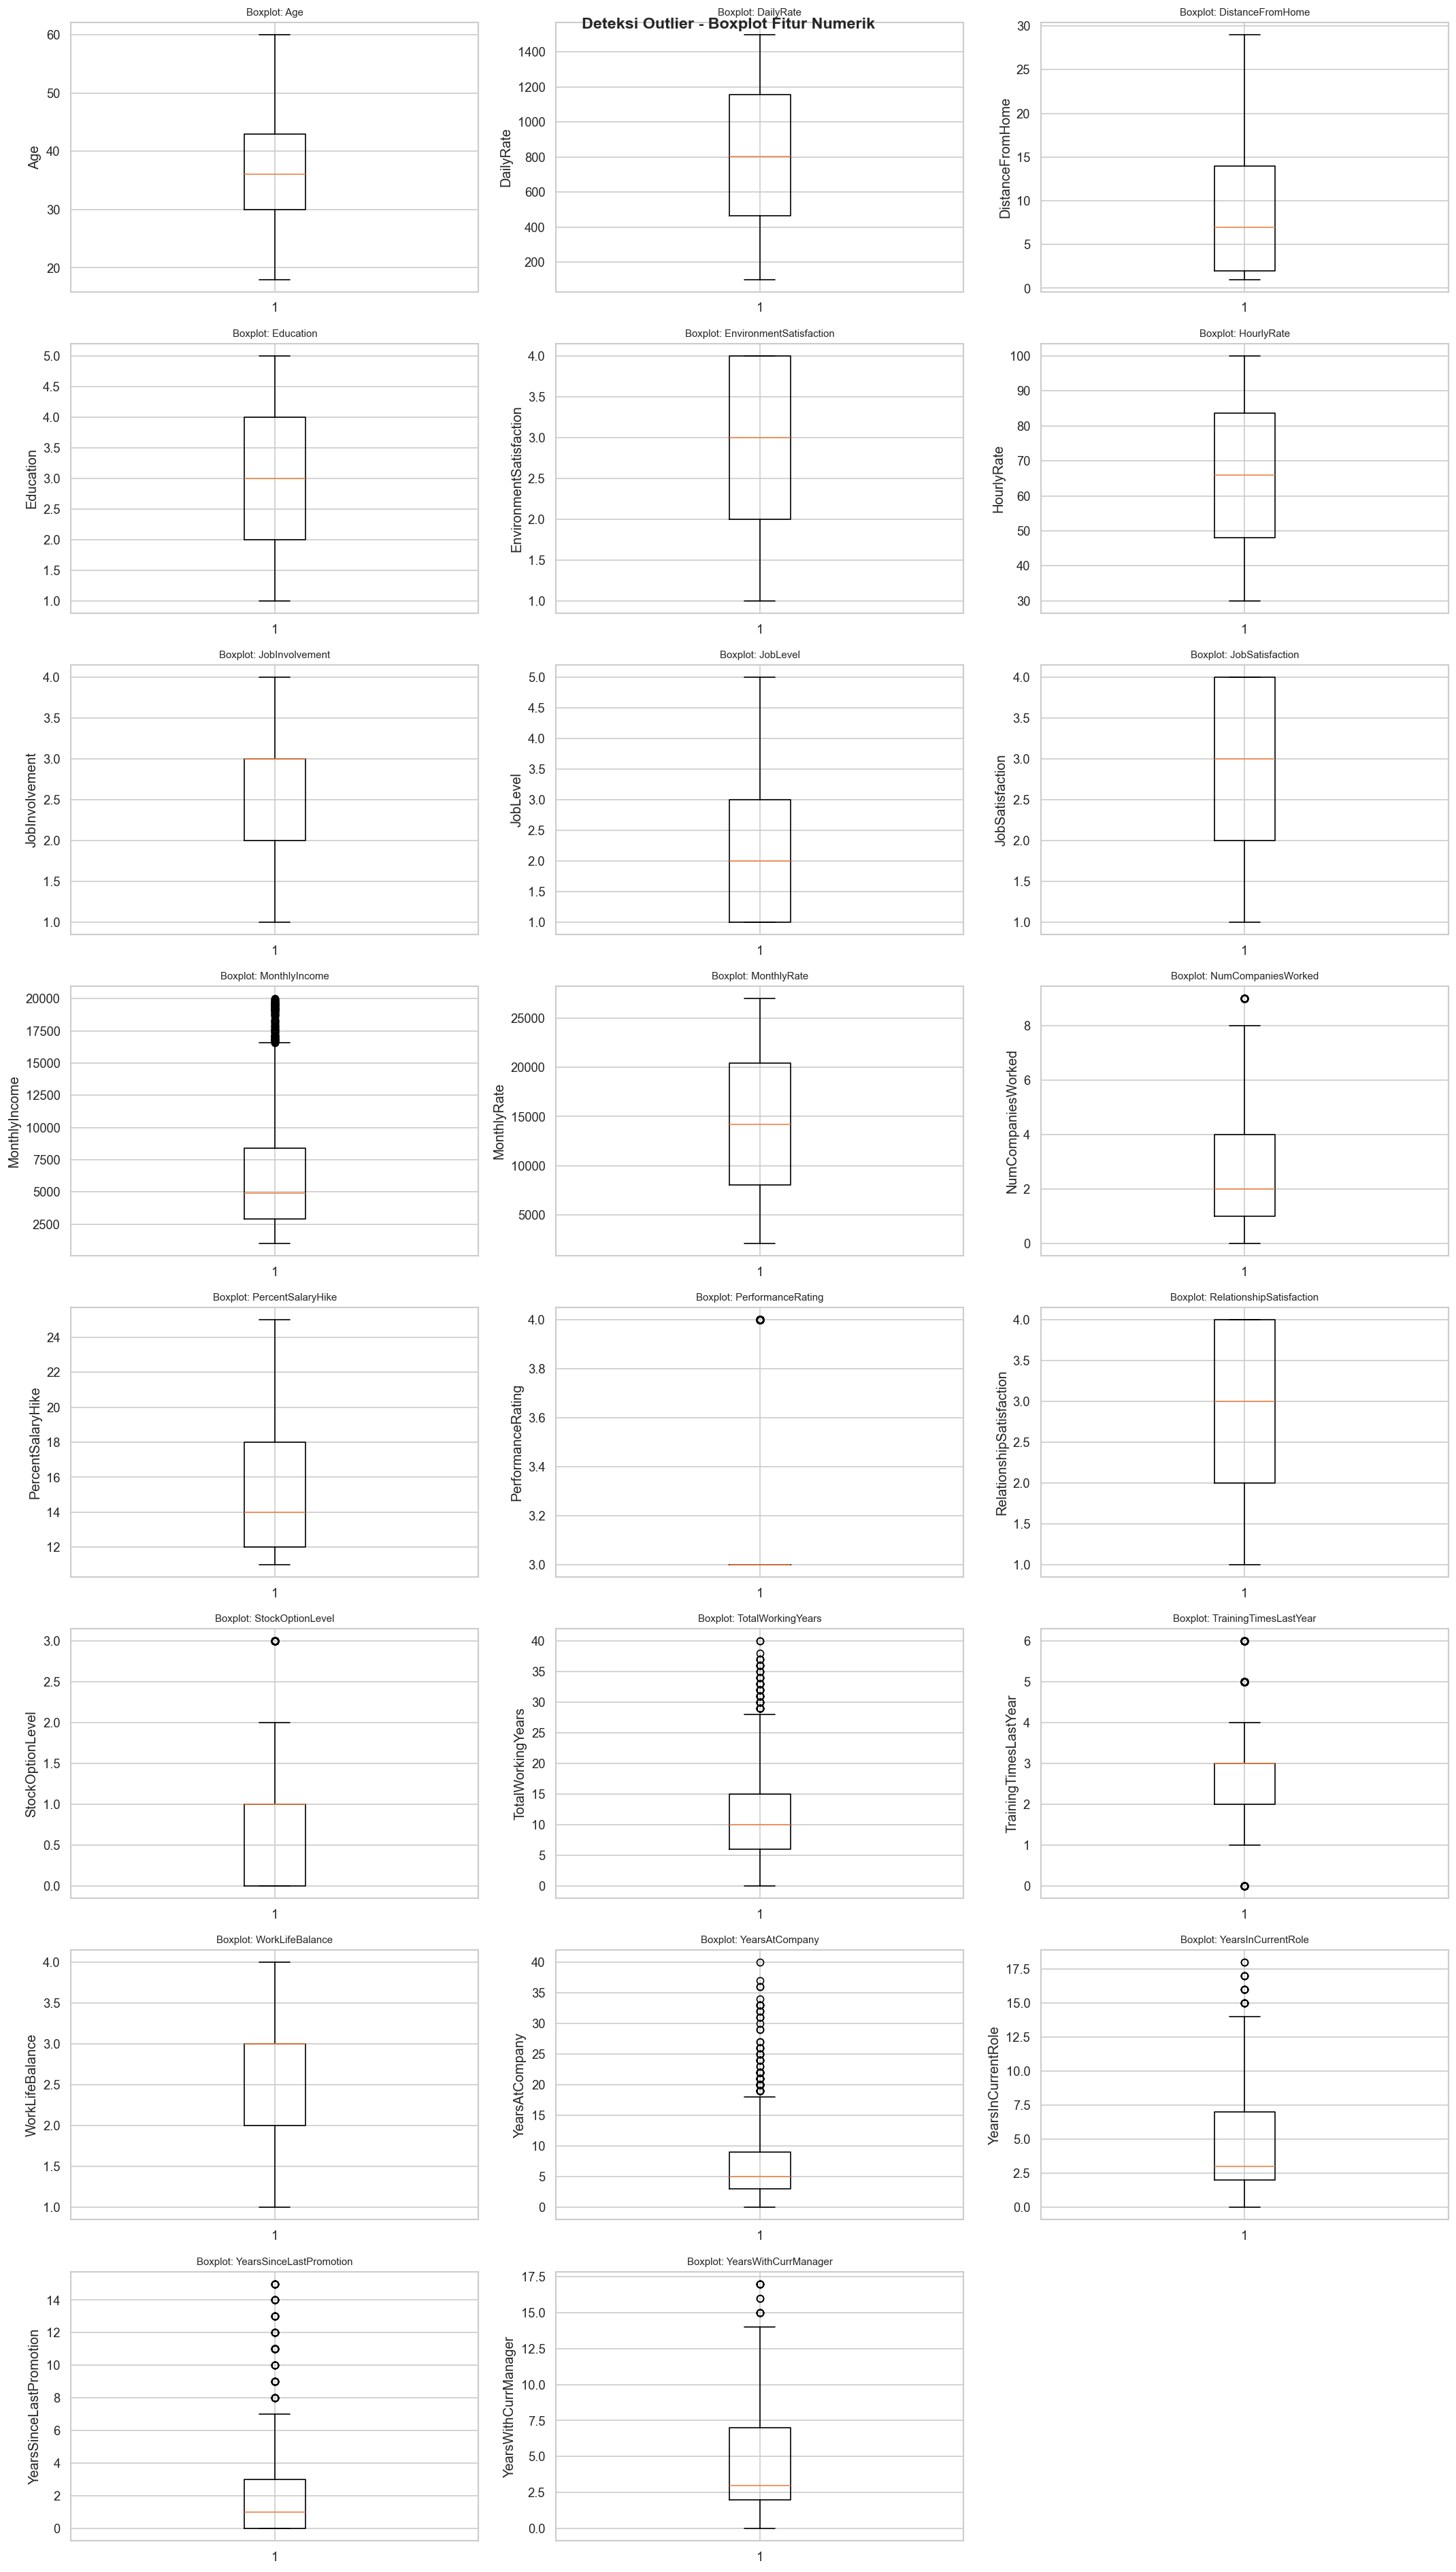

In [131]:
# Visualisasi outlier dengan boxplot
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features_plot = [col for col in num_features if col != 'Attrition']

n_cols = 3
n_rows = (len(num_features_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features_plot):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot: {col}', fontsize=9)
    axes[i].set_ylabel(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier - Boxplot Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [132]:
# Tangani outlier dengan IQR Capping
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_outliers > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'  ⚠️  {col}: {n_outliers} outlier di-cap (lower={lower:.2f}, upper={upper:.2f})')
    return df

# Skip kolom rating/skala bounded
bounded_cols = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                'JobLevel', 'JobSatisfaction', 'PerformanceRating',
                'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']
outlier_cols = [col for col in num_features_plot if col not in bounded_cols]

print('=== PENANGANAN OUTLIER (IQR Capping) ===')
for col in outlier_cols:
    df = cap_outliers_iqr(df, col)

print('\n✅ Outlier selesai ditangani!')

=== PENANGANAN OUTLIER (IQR Capping) ===
  ⚠️  MonthlyIncome: 114 outlier di-cap (lower=-5291.00, upper=16581.00)
  ⚠️  NumCompaniesWorked: 52 outlier di-cap (lower=-3.50, upper=8.50)
  ⚠️  TotalWorkingYears: 63 outlier di-cap (lower=-7.50, upper=28.50)
  ⚠️  TrainingTimesLastYear: 238 outlier di-cap (lower=0.50, upper=4.50)
  ⚠️  YearsAtCompany: 104 outlier di-cap (lower=-6.00, upper=18.00)
  ⚠️  YearsInCurrentRole: 21 outlier di-cap (lower=-5.50, upper=14.50)
  ⚠️  YearsSinceLastPromotion: 107 outlier di-cap (lower=-4.50, upper=7.50)
  ⚠️  YearsWithCurrManager: 14 outlier di-cap (lower=-5.50, upper=14.50)

✅ Outlier selesai ditangani!


### 3.5 Cek Konsistensi Data

In [133]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print('=== NILAI UNIK KOLOM KATEGORIKAL ===')
for col in cat_cols:
    print(f'\n📌 {col} ({df[col].nunique()} unik): {df[col].unique().tolist()}')

=== NILAI UNIK KOLOM KATEGORIKAL ===

📌 Attrition (2 unik): ['Yes', 'No']

📌 BusinessTravel (3 unik): ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']

📌 Department (3 unik): ['Sales', 'Research & Development', 'Human Resources']

📌 EducationField (6 unik): ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']

📌 Gender (2 unik): ['Female', 'Male']

📌 JobRole (9 unik): ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']

📌 MaritalStatus (3 unik): ['Single', 'Married', 'Divorced']

📌 OverTime (2 unik): ['Yes', 'No']


In [134]:
# Standardisasi format teks
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

print('✅ Format teks kolom kategorikal sudah dirapikan.')

# Distribusi target
print('\n=== DISTRIBUSI TARGET (Attrition) ===')
print(df['Attrition'].value_counts())
print(f'Proporsi: {df["Attrition"].value_counts(normalize=True).round(3).to_dict()}')

✅ Format teks kolom kategorikal sudah dirapikan.

=== DISTRIBUSI TARGET (Attrition) ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Proporsi: {'No': 0.839, 'Yes': 0.161}


---
##  4. DATA PREPROCESSING

### 4.1 Encoding Target Variable

In [135]:
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
    print('✅ Target Attrition di-encode: Yes=1, No=0')

print(f'Distribusi target setelah encoding:\n{df["Attrition"].value_counts()}')

Distribusi target setelah encoding:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


### 4.2 Encoding Fitur Kategorikal

In [136]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Attrition']

print(f'Kolom kategorikal yang akan di-encode: {cat_cols}')

binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
onehot_cols = [col for col in cat_cols if df[col].nunique() > 2]

print(f'\nBinary encoding: {binary_cols}')
print(f'One-Hot encoding: {onehot_cols}')

Kolom kategorikal yang akan di-encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Binary encoding: ['Gender', 'OverTime']
One-Hot encoding: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']


In [137]:
# Binary Encoding
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f'✅ Binary encode: {col} → {df[col].unique()}')

# One-Hot Encoding
if onehot_cols:
    df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)
    print(f'\n✅ One-Hot encode selesai: {onehot_cols}')

print(f'\n📊 Shape setelah encoding: {df.shape}')
df.head()

✅ Binary encode: Gender → [0 1]
✅ Binary encode: OverTime → [1 0]

✅ One-Hot encode selesai: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

📊 Shape setelah encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,Yes,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,No,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,Yes,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,No,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,No,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False


### 4.3 Pisah Fitur dan Target

In [138]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f'✅ Shape X (fitur): {X.shape}')
print(f'✅ Shape y (target): {y.shape}')
print(f'\nDistribusi kelas target:')
print(y.value_counts())
print(f'  → Class 0 (No Attrition): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'  → Class 1 (Attrition):    {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')

✅ Shape X (fitur): (1470, 44)
✅ Shape y (target): (1470,)

Distribusi kelas target:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
  → Class 0 (No Attrition): 0 (0.0%)
  → Class 1 (Attrition):    0 (0.0%)


### 4.4 Feature Scaling (Normalisasi)

In [139]:
bool_cols = X.select_dtypes(include=['bool', 'uint8']).columns.tolist()
scale_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
scale_cols = [col for col in scale_cols if col not in bool_cols]

# Gender & OverTime ke pengecualian (sudah di-encode jadi 0 dan 1)
binary_encoded = ['Gender', 'OverTime']
scale_cols = [col for col in scale_cols if col not in binary_encoded]

print(f'Kolom yang akan di-scale ({len(scale_cols)} kolom):')
print(scale_cols)

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print(f'\n✅ Scaling selesai dengan StandardScaler')
print(f'Contoh sebelum scaling (MonthlyIncome):')
print(f'  Mean={X["MonthlyIncome"].mean():.2f}, Std={X["MonthlyIncome"].std():.2f}')
print(f'Contoh setelah scaling:')
print(f'  Mean={X_scaled["MonthlyIncome"].mean():.4f}, Std={X_scaled["MonthlyIncome"].std():.4f}')

Kolom yang akan di-scale (23 kolom):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

✅ Scaling selesai dengan StandardScaler
Contoh sebelum scaling (MonthlyIncome):
  Mean=6361.89, Std=4353.35
Contoh setelah scaling:
  Mean=-0.0000, Std=1.0003


---
##  5. FEATURE ENGINEERING

### 5.1 Buat Fitur Baru dari Kolom yang Ada

In [140]:
df_fe = df.copy()

# ── FITUR 1: Salary-to-Experience Ratio
# Apakah karyawan dibayar sesuai pengalamannya?
if 'MonthlyIncome' in df_fe.columns and 'TotalWorkingYears' in df_fe.columns:
    df_fe['Salary_Experience_Ratio'] = df_fe['MonthlyIncome'] / (df_fe['TotalWorkingYears'] + 1)
    print('✅ Salary_Experience_Ratio = MonthlyIncome / (TotalWorkingYears + 1)')

# ── FITUR 2: Career Stagnation Ratio
# Lama di role yang sama vs total di perusahaan
if 'YearsInCurrentRole' in df_fe.columns and 'YearsAtCompany' in df_fe.columns:
    df_fe['Career_Stagnation_Ratio'] = df_fe['YearsInCurrentRole'] / (df_fe['YearsAtCompany'] + 1)
    print('✅ Career_Stagnation_Ratio = YearsInCurrentRole / (YearsAtCompany + 1)')

# ── FITUR 3: Overall Satisfaction Index
# Rata-rata kepuasan keseluruhan karyawan
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'JobInvolvement']
available_sat = [col for col in satisfaction_cols if col in df_fe.columns]
if available_sat:
    df_fe['Overall_Satisfaction_Index'] = df_fe[available_sat].mean(axis=1)
    print(f'✅ Overall_Satisfaction_Index = mean({available_sat})')

# ── FITUR 4: Promotion Gap Flag
# Sudah lama tidak dipromosi (> 3 tahun)
if 'YearsSinceLastPromotion' in df_fe.columns:
    df_fe['Long_No_Promotion'] = (df_fe['YearsSinceLastPromotion'] > 3).astype(int)
    print('✅ Long_No_Promotion = 1 jika YearsSinceLastPromotion > 3')

# ── FITUR 5: OverTime Risk Flag
# Karyawan yang overtime (sudah di-encode: 1=Yes)
if 'OverTime' in df_fe.columns:
    df_fe['Is_Overworked'] = df_fe['OverTime'].astype(int)
    print('✅ Is_Overworked = OverTime (1=Ya, 0=Tidak)')

# ── FITUR 6: Income vs Job Level Ratio
# Apakah gaji sesuai dengan level jabatan?
if 'MonthlyIncome' in df_fe.columns and 'JobLevel' in df_fe.columns:
    df_fe['Income_JobLevel_Ratio'] = df_fe['MonthlyIncome'] / df_fe['JobLevel']
    print('✅ Income_JobLevel_Ratio = MonthlyIncome / JobLevel')

# ── FITUR 7: Age Group
# Binning usia menjadi kategori generasi
if 'Age' in df_fe.columns:
    bins = [0, 25, 35, 45, 100]
    labels = ['Gen_Z', 'Millennial', 'Gen_X', 'Boomer']
    df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=bins, labels=labels, right=False)
    df_fe = pd.get_dummies(df_fe, columns=['Age_Group'], drop_first=True)
    print('✅ Age_Group = binning usia (Gen_Z / Millennial / Gen_X / Boomer)')

print(f'\n📊 Shape setelah feature engineering: {df_fe.shape}')

✅ Salary_Experience_Ratio = MonthlyIncome / (TotalWorkingYears + 1)
✅ Career_Stagnation_Ratio = YearsInCurrentRole / (YearsAtCompany + 1)
✅ Overall_Satisfaction_Index = mean(['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'JobInvolvement'])
✅ Long_No_Promotion = 1 jika YearsSinceLastPromotion > 3
✅ Is_Overworked = OverTime (1=Ya, 0=Tidak)
✅ Income_JobLevel_Ratio = MonthlyIncome / JobLevel
✅ Age_Group = binning usia (Gen_Z / Millennial / Gen_X / Boomer)

📊 Shape setelah feature engineering: (1470, 54)


### 5.2 Ringkasan Fitur Baru

In [141]:
new_features = [
    'Salary_Experience_Ratio', 'Career_Stagnation_Ratio',
    'Overall_Satisfaction_Index', 'Long_No_Promotion',
    'Is_Overworked', 'Income_JobLevel_Ratio'
]
existing_new = [f for f in new_features if f in df_fe.columns]

print('=== STATISTIK FITUR BARU ===')
print(df_fe[existing_new].describe().round(3))

=== STATISTIK FITUR BARU ===
       Salary_Experience_Ratio  Career_Stagnation_Ratio  \
count                 1470.000                 1470.000   
mean                   584.747                    0.486   
std                    281.563                    0.273   
min                     95.286                    0.000   
25%                    378.667                    0.333   
50%                    558.293                    0.500   
75%                    720.913                    0.667   
max                   1904.000                    0.875   

       Overall_Satisfaction_Index  Long_No_Promotion  Is_Overworked  \
count                    1470.000           1470.000       1470.000   
mean                        2.723              0.218          0.283   
std                         0.504              0.413          0.451   
min                         1.250              0.000          0.000   
25%                         2.500              0.000          0.000   
50%          

### 5.3 Korelasi Fitur Baru dengan Target

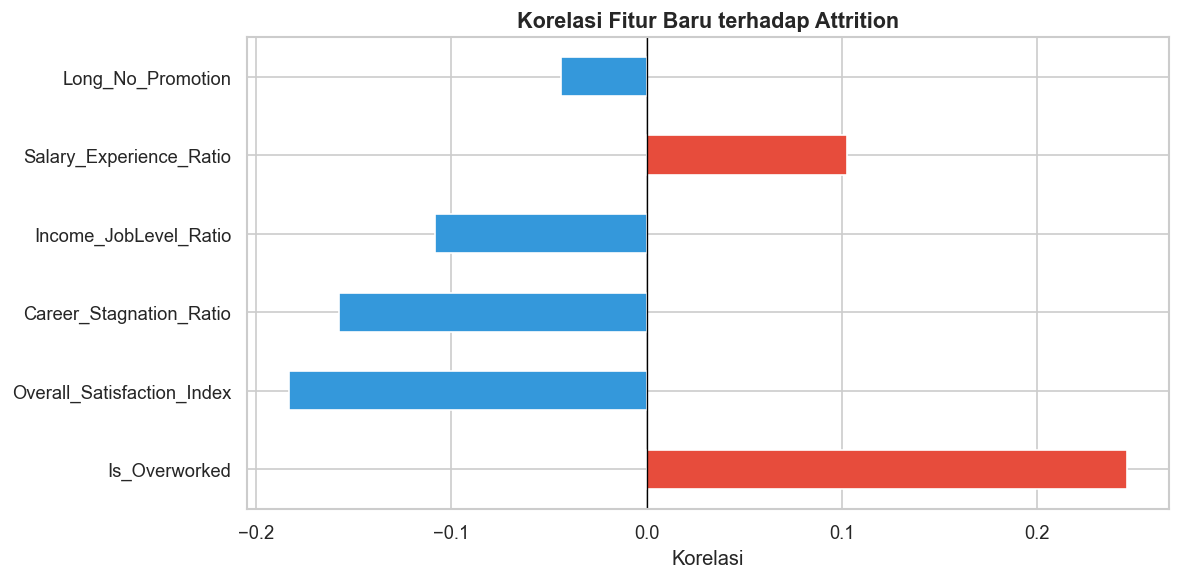

Nilai korelasi fitur baru:
Is_Overworked                 0.2461
Overall_Satisfaction_Index   -0.1831
Career_Stagnation_Ratio      -0.1575
Income_JobLevel_Ratio        -0.1083
Salary_Experience_Ratio       0.1026
Long_No_Promotion            -0.0437
Name: Attrition, dtype: float64


In [142]:
# ✅ FIX: Force convert Attrition ke int
df_fe['Attrition'] = df_fe['Attrition'].replace({'Yes': 1, 'No': 0}).astype(int)

target_corr = df_fe[existing_new + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title('Korelasi Fitur Baru terhadap Attrition', fontsize=13, fontweight='bold')
plt.xlabel('Korelasi')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Nilai korelasi fitur baru:')
print(target_corr.round(4))

### 5.4 Re-scaling Setelah Feature Engineering

In [143]:
X_final = df_fe.drop(columns=['Attrition'])
y_final = df_fe['Attrition']

bool_cols_fe = X_final.select_dtypes(include=['bool', 'uint8']).columns.tolist()
scale_cols_fe = X_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
scale_cols_fe = [col for col in scale_cols_fe if col not in bool_cols_fe]

# Kecualikan kolom binary encoded
binary_encoded = ['Gender', 'OverTime', 'Is_Overworked', 'Long_No_Promotion']
scale_cols_fe = [col for col in scale_cols_fe if col not in binary_encoded]

scaler_final = StandardScaler()
X_final_scaled = X_final.copy()
X_final_scaled[scale_cols_fe] = scaler_final.fit_transform(X_final[scale_cols_fe])

print(f'✅ Final X shape (siap untuk modeling): {X_final_scaled.shape}')
print(f'✅ Final y shape: {y_final.shape}')
X_final_scaled.head()

✅ Final X shape (siap untuk modeling): (1470, 53)
✅ Final y shape: (1470,)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,MaritalStatus_Single,Salary_Experience_Ratio,Career_Stagnation_Ratio,Overall_Satisfaction_Index,Long_No_Promotion,Is_Overworked,Income_JobLevel_Ratio,Age_Group_Millennial,Age_Group_Gen_X,Age_Group_Boomer
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,0,1.383138,0.379672,-0.057788,1.153254,...,True,0.288283,0.312425,-0.442844,0,1,0.069844,False,True,False
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,1,-0.240677,-1.026167,-0.057788,-0.660853,...,False,-0.420592,0.550630,0.053330,0,0,-0.511610,False,False,True
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1,1.284725,-1.026167,-0.961486,0.246200,...,True,-1.149322,-1.783771,0.053330,0,1,-1.151682,False,True,False
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,0,-0.486709,0.379672,-0.961486,0.246200,...,False,-0.929146,1.069385,1.045679,0,1,-0.048064,True,False,False
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,1,-1.274014,0.379672,-0.961486,-0.660853,...,False,-0.317330,0.661791,-0.442844,0,0,0.705199,True,False,False


---
##  6. Simpan Hasil Data Preparation

In [144]:
df_fe.to_csv('../data/employee_attrition_clean.csv', index=False)
X_final_scaled.to_csv('../data/X_preprocessed.csv', index=False)
y_final.to_csv('../data/y_target.csv', index=False)
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler_final, '../models/scaler.pkl')
print('✅ Scaler tersimpan: ../models/scaler.pkl')

print('✅ File tersimpan:')
print('  - ../data/employee_attrition_clean.csv  → dataset lengkap setelah cleaning + FE')
print('  - ../data/X_preprocessed.csv            → fitur siap modeling (sudah scaled)')
print('  - ../data/y_target.csv                  → label target')

✅ Scaler tersimpan: ../models/scaler.pkl
✅ File tersimpan:
  - ../data/employee_attrition_clean.csv  → dataset lengkap setelah cleaning + FE
  - ../data/X_preprocessed.csv            → fitur siap modeling (sudah scaled)
  - ../data/y_target.csv                  → label target


---
##  7. Ringkasan Data Preparation

In [145]:
print('=' * 55)
print('RINGKASAN DATA PREPARATION'.center(55))
print('=' * 55)

print(f'\n📌 DATASET AWAL')
print(f'   Dataset       : IBM HR Analytics Employee Attrition')
print(f'   Shape         : {df_original.shape}')

print(f'\n🧹 DATA CLEANING')
print(f'   Missing values: Ditangani (median/modus)')
print(f'   Duplikat      : Dihapus')
print(f'   Kolom dihapus : EmployeeNumber, EmployeeCount, Over18, StandardHours')
print(f'   Outlier       : Di-cap dengan IQR method')

print(f'\n⚙️  DATA PREPROCESSING')
print(f'   Target encode : Yes=1, No=0')
print(f'   Cat. encode   : Binary (Label) + One-Hot')
print(f'   Scaling       : StandardScaler (kecuali binary encoded)')

print(f'\n🔧 FEATURE ENGINEERING (7 fitur baru)')
print(f'   1. Salary_Experience_Ratio')
print(f'   2. Career_Stagnation_Ratio')
print(f'   3. Overall_Satisfaction_Index')
print(f'   4. Long_No_Promotion (flag)')
print(f'   5. Is_Overworked (flag)')
print(f'   6. Income_JobLevel_Ratio')
print(f'   7. Age_Group (binning → dummy)')

print(f'\n📊 DATASET FINAL')
print(f'   Shape X       : {X_final_scaled.shape}')
print(f'   Shape y       : {y_final.shape}')
print(f'   Attrition=1   : {y_final.sum()} ({y_final.mean()*100:.1f}%)')
print(f'   Attrition=0   : {(y_final==0).sum()} ({(y_final==0).mean()*100:.1f}%)')
print('=' * 55)

               RINGKASAN DATA PREPARATION              

📌 DATASET AWAL
   Dataset       : IBM HR Analytics Employee Attrition
   Shape         : (1470, 35)

🧹 DATA CLEANING
   Missing values: Ditangani (median/modus)
   Duplikat      : Dihapus
   Kolom dihapus : EmployeeNumber, EmployeeCount, Over18, StandardHours
   Outlier       : Di-cap dengan IQR method

⚙️  DATA PREPROCESSING
   Target encode : Yes=1, No=0
   Cat. encode   : Binary (Label) + One-Hot
   Scaling       : StandardScaler (kecuali binary encoded)

🔧 FEATURE ENGINEERING (7 fitur baru)
   1. Salary_Experience_Ratio
   2. Career_Stagnation_Ratio
   3. Overall_Satisfaction_Index
   4. Long_No_Promotion (flag)
   5. Is_Overworked (flag)
   6. Income_JobLevel_Ratio
   7. Age_Group (binning → dummy)

📊 DATASET FINAL
   Shape X       : (1470, 53)
   Shape y       : (1470,)
   Attrition=1   : 237 (16.1%)
   Attrition=0   : 1233 (83.9%)


#  Exploratory Data Analysis — Employee Attrition Risk Prediction
**Dikerjakan oleh:** Nailah Fauziyyah

**Tanggung jawab:**
- ✅ Analisis karakteristik data
- ✅ Visualisasi data
- ✅ Insight dan storytelling

**Dataset:** IBM HR Analytics Employee Attrition (sudah melalui tahap Data Preparation oleh Zahra Daniah)

---


## 📦 1. Import Library

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

ATTRITION_COLORS = {0: '#4C72B0', 1: '#DD8452'}   # biru = stay, oranye = resign
ACCENT = '#DD8452'
PRIMARY = '#4C72B0'

print('✅ Library berhasil diimport')


✅ Library berhasil diimport


##  2. Load Dataset

In [147]:
df = pd.read_csv('../data/employee_attrition_clean.csv')

print(f'📊 Shape dataset : {df.shape}')
print(f'📋 Jumlah baris  : {df.shape[0]:,}')
print(f'📋 Jumlah kolom  : {df.shape[1]}')
df.head()


📊 Shape dataset : (1470, 54)
📋 Jumlah baris  : 1,470
📋 Jumlah kolom  : 54


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,MaritalStatus_Single,Salary_Experience_Ratio,Career_Stagnation_Ratio,Overall_Satisfaction_Index,Long_No_Promotion,Is_Overworked,Income_JobLevel_Ratio,Age_Group_Millennial,Age_Group_Gen_X,Age_Group_Boomer
0,41,1,1102,1,2,2,0,94,3,2,...,True,665.888889,0.571429,2.50,0,1,2996.5,False,True,False
1,49,0,279,8,1,3,1,61,2,2,...,False,466.363636,0.636364,2.75,0,0,2565.0,False,False,True
2,37,1,1373,2,2,4,1,92,2,1,...,True,261.250000,0.000000,2.75,0,1,2090.0,False,True,False
3,33,0,1392,3,4,4,0,56,3,1,...,False,323.222222,0.777778,3.25,0,1,2909.0,True,False,False
4,27,0,591,2,1,1,1,40,3,1,...,False,495.428571,0.666667,2.50,0,0,3468.0,True,False,False


In [148]:
print('=== INFO DATASET ===')
df.info()


=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   int64  
 1   Attrition                          1470 non-null   int64  
 2   DailyRate                          1470 non-null   int64  
 3   DistanceFromHome                   1470 non-null   int64  
 4   Education                          1470 non-null   int64  
 5   EnvironmentSatisfaction            1470 non-null   int64  
 6   Gender                             1470 non-null   int64  
 7   HourlyRate                         1470 non-null   int64  
 8   JobInvolvement                     1470 non-null   int64  
 9   JobLevel                           1470 non-null   int64  
 10  JobSatisfaction                    1470 non-null   int64  
 11  MonthlyIncome                      1470 non-nu

In [149]:
print('=== STATISTIK DESKRIPTIF ===')
df.describe().T


=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.000000,30.000000,36.000000,43.000000,60.000
Attrition,1470.0,0.161224,0.367863,0.000000,0.000000,0.000000,0.000000,1.000
DailyRate,1470.0,802.485714,403.509100,102.000000,465.000000,802.000000,1157.000000,1499.000
DistanceFromHome,1470.0,9.192517,8.106864,1.000000,2.000000,7.000000,14.000000,29.000
Education,1470.0,2.912925,1.024165,1.000000,2.000000,3.000000,4.000000,5.000
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.000000,2.000000,3.000000,4.000000,4.000
Gender,1470.0,0.600000,0.490065,0.000000,0.000000,1.000000,1.000000,1.000
HourlyRate,1470.0,65.891156,20.329428,30.000000,48.000000,66.000000,83.750000,100.000
JobInvolvement,1470.0,2.729932,0.711561,1.000000,2.000000,3.000000,3.000000,4.000
JobLevel,1470.0,2.063946,1.106940,1.000000,1.000000,2.000000,3.000000,5.000


##  3. Distribusi Target Variable (Attrition)

Sebelum melangkah lebih jauh, kita perlu memahami proporsi kelas target agar analisis kita tepat sasaran.


=== DISTRIBUSI TARGET ===
  Stay   (0) : 1,233 karyawan (83.9%)
  Resign (1) : 237 karyawan (16.1%)


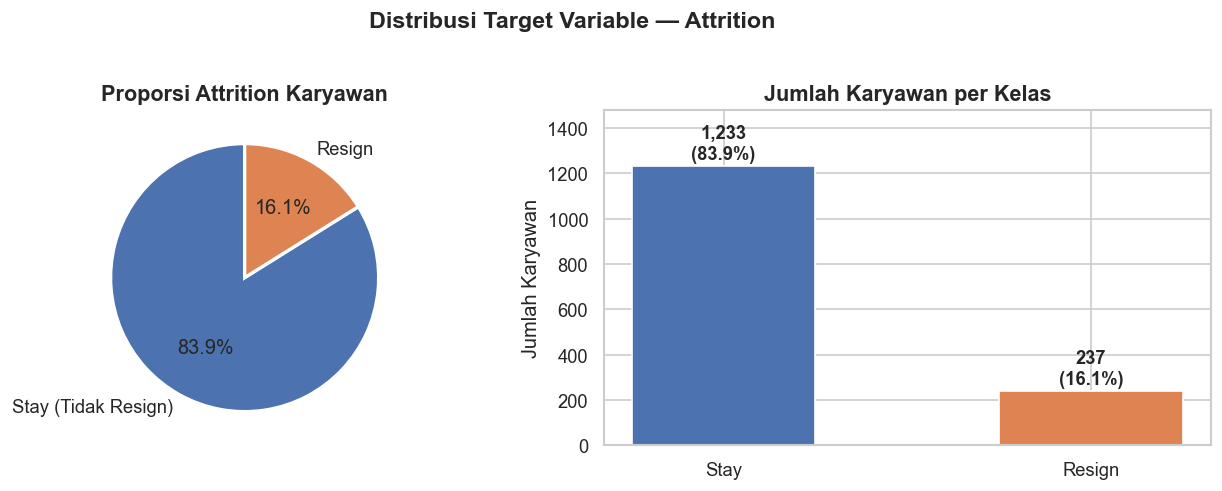


💡 Insight:
   Dataset bersifat IMBALANCED — hanya 16.1% karyawan yang resign.
   Hal ini perlu diperhatikan saat modeling (gunakan SMOTE / class weighting).


In [150]:
import os
os.makedirs('../presentation', exist_ok=True)

attrition_counts = df['Attrition'].value_counts().sort_index()
attrition_pct    = df['Attrition'].value_counts(normalize=True).sort_index() * 100

print('=== DISTRIBUSI TARGET ===')
print(f"  Stay   (0) : {attrition_counts.loc[0]:,} karyawan ({attrition_pct.loc[0]:.1f}%)")
print(f"  Resign (1) : {attrition_counts.loc[1]:,} karyawan ({attrition_pct.loc[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie chart
labels = ['Stay (Tidak Resign)', 'Resign']
colors = [ATTRITION_COLORS[0], ATTRITION_COLORS[1]]
axes[0].pie(
    attrition_counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporsi Attrition Karyawan', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(
    ['Stay', 'Resign'],
    attrition_counts.values,
    color=colors,
    edgecolor='white',
    width=0.5
)
for bar, cnt, pct in zip(bars, attrition_counts.values, attrition_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 15,
                 f'{cnt:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Jumlah Karyawan per Kelas', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Karyawan')
axes[1].set_ylim(0, attrition_counts.loc[0] * 1.2)

plt.suptitle('Distribusi Target Variable — Attrition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../presentation/eda_01_target_distribution.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight:')
print(f'   Dataset bersifat IMBALANCED — hanya {attrition_pct.loc[1]:.1f}% karyawan yang resign.')
print('   Hal ini perlu diperhatikan saat modeling (gunakan SMOTE / class weighting).')

##  4. Analisis Demografis

### 4.1 Distribusi Usia dan Kelompok Generasi


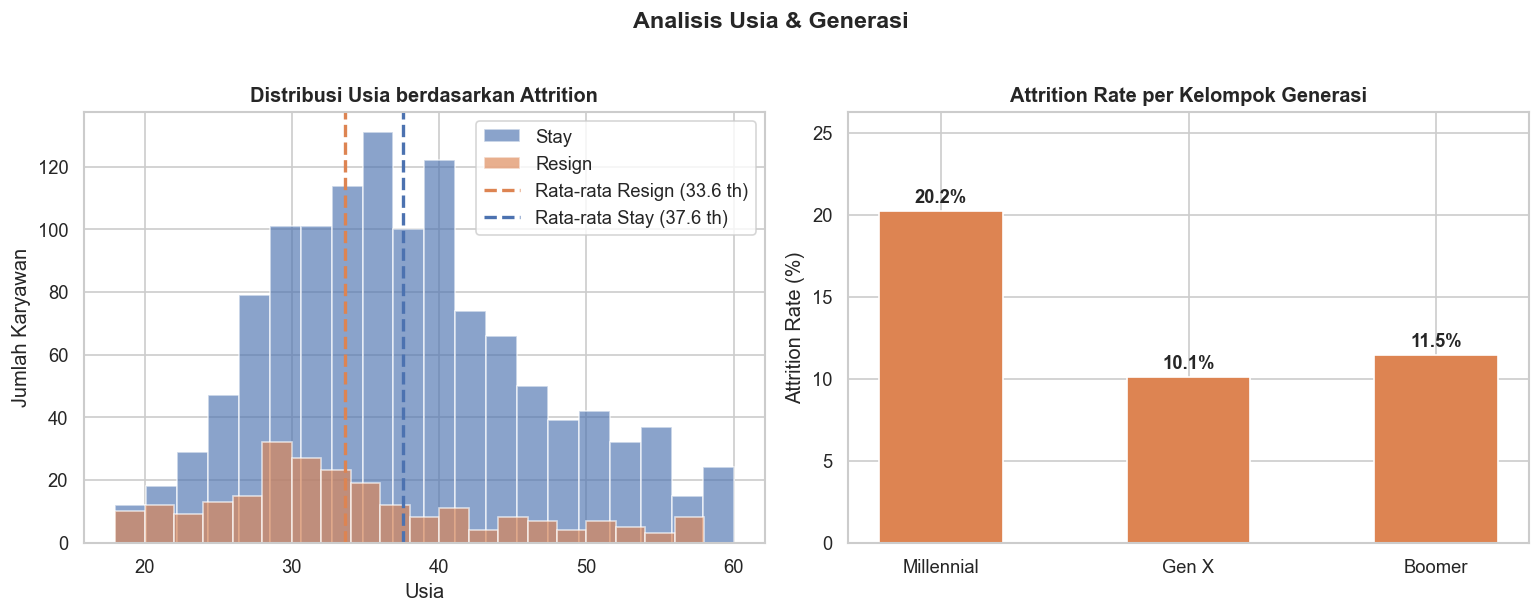


💡 Insight:
   Millennial (25–40 th) memiliki attrition rate tertinggi dibanding generasi lain.
   Rata-rata usia karyawan yang resign (~33 th) lebih muda dari yang stay (~37 th).
   Karyawan muda cenderung lebih terbuka terhadap peluang karir baru.


In [151]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram usia
for val, label in [(0,'Stay'), (1,'Resign')]:
    subset = df[df['Attrition'] == val]['Age']
    axes[0].hist(subset, bins=20, alpha=0.65,
                 color=ATTRITION_COLORS[val], label=label, edgecolor='white')
axes[0].axvline(df[df['Attrition']==1]['Age'].mean(), color=ATTRITION_COLORS[1],
                linestyle='--', linewidth=2,
                label=f"Rata-rata Resign ({df[df['Attrition']==1]['Age'].mean():.1f} th)")
axes[0].axvline(df[df['Attrition']==0]['Age'].mean(), color=ATTRITION_COLORS[0],
                linestyle='--', linewidth=2,
                label=f"Rata-rata Stay ({df[df['Attrition']==0]['Age'].mean():.1f} th)")
axes[0].set_title('Distribusi Usia berdasarkan Attrition', fontweight='bold')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Jumlah Karyawan')
axes[0].legend()

# Attrition rate per generasi
gen_map = {'Millennial': 'Age_Group_Millennial',
           'Gen X': 'Age_Group_Gen_X',
           'Boomer': 'Age_Group_Boomer'}
gen_rates = {name: df[df[col]==True]['Attrition'].mean()*100
             for name, col in gen_map.items()}
bars = axes[1].bar(gen_rates.keys(), gen_rates.values(),
                   color=[ACCENT]*3, edgecolor='white', width=0.5)
for bar, val in zip(bars, gen_rates.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Attrition Rate per Kelompok Generasi', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, max(gen_rates.values()) * 1.3)

plt.suptitle('Analisis Usia & Generasi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../presentation/eda_02_age_generation.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight:')
print('   Millennial (25–40 th) memiliki attrition rate tertinggi dibanding generasi lain.')
print('   Rata-rata usia karyawan yang resign (~33 th) lebih muda dari yang stay (~37 th).')
print('   Karyawan muda cenderung lebih terbuka terhadap peluang karir baru.')


### 4.2 Attrition berdasarkan Jenis Kelamin & Status Pernikahan

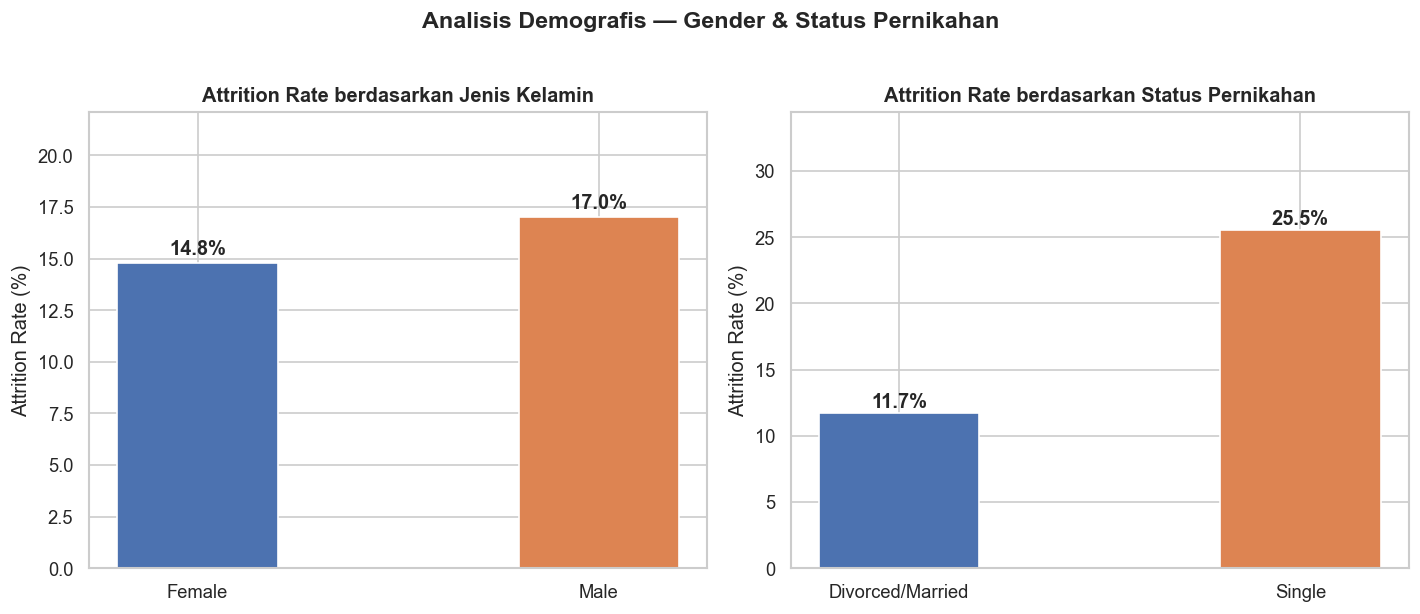


💡 Insight:
   Karyawan SINGLE memiliki attrition rate ~25.5%, jauh lebih tinggi dari yang menikah (~11.7%).
   Tanggung jawab keluarga kemungkinan membuat karyawan menikah lebih mempertahankan posisinya.


In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender (0=Female, 1=Male based on LabelEncoder)
gender_rate = df.groupby('Gender')['Attrition'].mean() * 100
gender_labels = ['Female', 'Male']
bars = axes[0].bar(gender_labels, gender_rate.values,
                   color=[PRIMARY, ACCENT], edgecolor='white', width=0.4)
for bar, val in zip(bars, gender_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Attrition Rate berdasarkan Jenis Kelamin', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, gender_rate.max() * 1.3)

# Marital status
marital_data = {
    'Divorced/Married': df[df['MaritalStatus_Single']==False]['Attrition'].mean()*100,
    'Single': df[df['MaritalStatus_Single']==True]['Attrition'].mean()*100
}
bars = axes[1].bar(marital_data.keys(), marital_data.values(),
                   color=[PRIMARY, ACCENT], edgecolor='white', width=0.4)
for bar, val in zip(bars, marital_data.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Attrition Rate berdasarkan Status Pernikahan', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, marital_data['Single'] * 1.35)

plt.suptitle('Analisis Demografis — Gender & Status Pernikahan',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../presentation/eda_03_gender_marital.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight:')
print('   Karyawan SINGLE memiliki attrition rate ~25.5%, jauh lebih tinggi dari yang menikah (~11.7%).')
print('   Tanggung jawab keluarga kemungkinan membuat karyawan menikah lebih mempertahankan posisinya.')


##  5. Analisis Faktor Pekerjaan

### 5.1 Attrition berdasarkan Departemen & Job Role

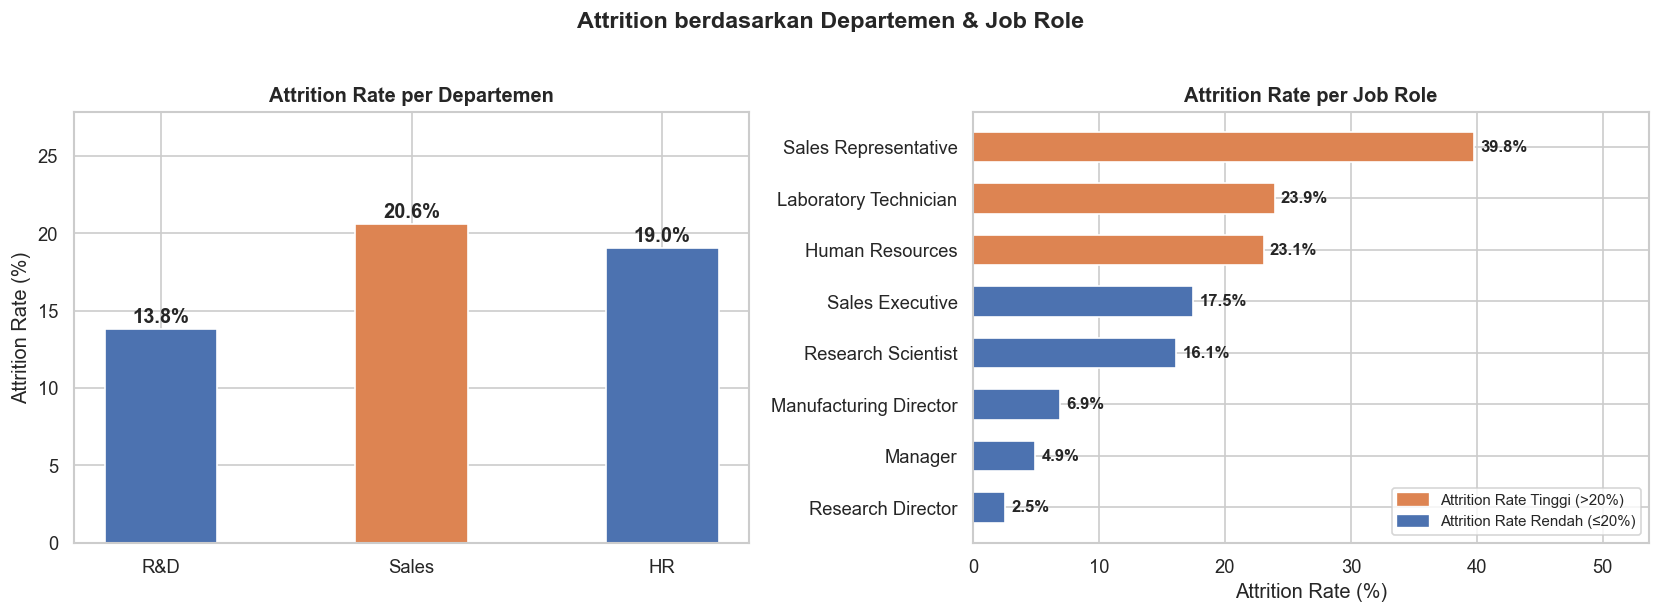


💡 Insight:
   Sales Representative memiliki attrition rate TERTINGGI (~39.8%).
   Research Director & Manager memiliki attrition rate TERENDAH (<7%).
   Departemen Sales secara keseluruhan paling rentan kehilangan karyawan.


In [153]:
# Departemen
dept_data = {
    'R&D': df[df['Department_Research & Development']==True]['Attrition'].mean()*100,
    'Sales': df[df['Department_Sales']==True]['Attrition'].mean()*100,
    'HR': df[(df['Department_Research & Development']==False) &
             (df['Department_Sales']==False)]['Attrition'].mean()*100
}

# Job Role
jobrole_cols = [c for c in df.columns if c.startswith('JobRole_')]
jobrole_rates = {}
for col in jobrole_cols:
    name = col.replace('JobRole_', '')
    mask = df[col] == True
    if mask.sum() > 0:
        jobrole_rates[name] = df[mask]['Attrition'].mean() * 100
jobrole_df = pd.Series(jobrole_rates).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dept bar
colors_dept = [ACCENT if v == max(dept_data.values()) else PRIMARY
               for v in dept_data.values()]
bars = axes[0].bar(dept_data.keys(), dept_data.values(),
                   color=colors_dept, edgecolor='white', width=0.45)
for bar, val in zip(bars, dept_data.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Attrition Rate per Departemen', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, max(dept_data.values()) * 1.35)

# Job Role horizontal bar
bar_colors = [ACCENT if v > 20 else PRIMARY for v in jobrole_df.values]
bars2 = axes[1].barh(jobrole_df.index, jobrole_df.values,
                     color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars2, jobrole_df.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[1].set_title('Attrition Rate per Job Role', fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_xlim(0, jobrole_df.max() * 1.35)

patch_high = mpatches.Patch(color=ACCENT, label='Attrition Rate Tinggi (>20%)')
patch_low  = mpatches.Patch(color=PRIMARY, label='Attrition Rate Rendah (≤20%)')
axes[1].legend(handles=[patch_high, patch_low], loc='lower right', fontsize=9)

plt.suptitle('Attrition berdasarkan Departemen & Job Role',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../presentation/eda_04_dept_jobrole.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight:')
print('   Sales Representative memiliki attrition rate TERTINGGI (~39.8%).')
print('   Research Director & Manager memiliki attrition rate TERENDAH (<7%).')
print('   Departemen Sales secara keseluruhan paling rentan kehilangan karyawan.')


### 5.2 Attrition berdasarkan Job Level & OverTime

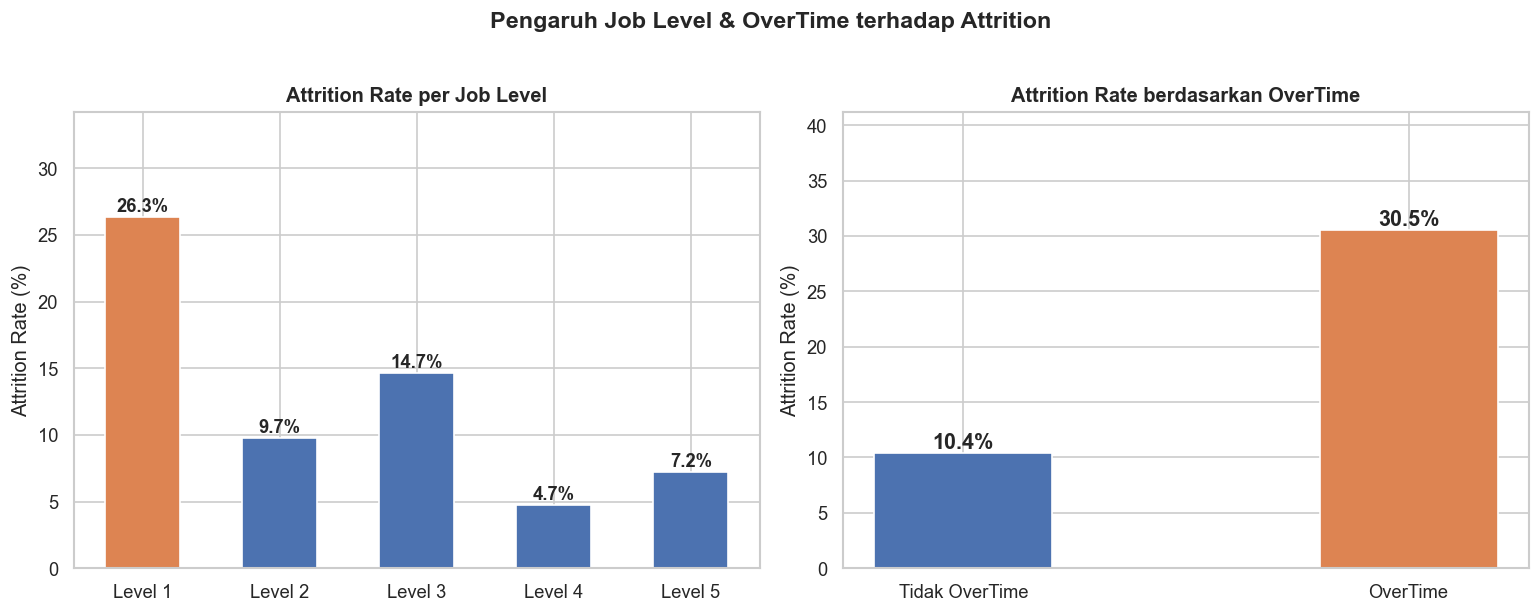


💡 Insight:
   Job Level 1 (entry-level) memiliki attrition rate ~26.3% — 5x lebih tinggi dari Level 4.
   Karyawan yang OverTime resign 3x lebih banyak (30.5%) vs yang tidak (10.4%).
   OverTime adalah salah satu sinyal risiko paling kuat dalam dataset ini.


In [154]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Job Level
jl_rate = df.groupby('JobLevel')['Attrition'].mean() * 100
colors_jl = [ACCENT if v > 15 else PRIMARY for v in jl_rate.values]
bars = axes[0].bar(
    [f'Level {l}' for l in jl_rate.index],
    jl_rate.values,
    color=colors_jl, edgecolor='white', width=0.55
)
for bar, val in zip(bars, jl_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Attrition Rate per Job Level', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, jl_rate.max() * 1.3)

# OverTime
ot_rate = df.groupby('OverTime')['Attrition'].mean() * 100
labels_ot = ['Tidak OverTime', 'OverTime']
colors_ot = [PRIMARY, ACCENT]
bars2 = axes[1].bar(labels_ot, ot_rate.values,
                    color=colors_ot, edgecolor='white', width=0.4)
for bar, val in zip(bars2, ot_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[1].set_title('Attrition Rate berdasarkan OverTime', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, ot_rate.max() * 1.35)

plt.suptitle('Pengaruh Job Level & OverTime terhadap Attrition',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../presentation/eda_05_joblevel_overtime.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight:')
print('   Job Level 1 (entry-level) memiliki attrition rate ~26.3% — 5x lebih tinggi dari Level 4.')
print('   Karyawan yang OverTime resign 3x lebih banyak (30.5%) vs yang tidak (10.4%).')
print('   OverTime adalah salah satu sinyal risiko paling kuat dalam dataset ini.')


##  6. Analisis Kompensasi & Kepuasan

### 6.1 Monthly Income berdasarkan Attrition

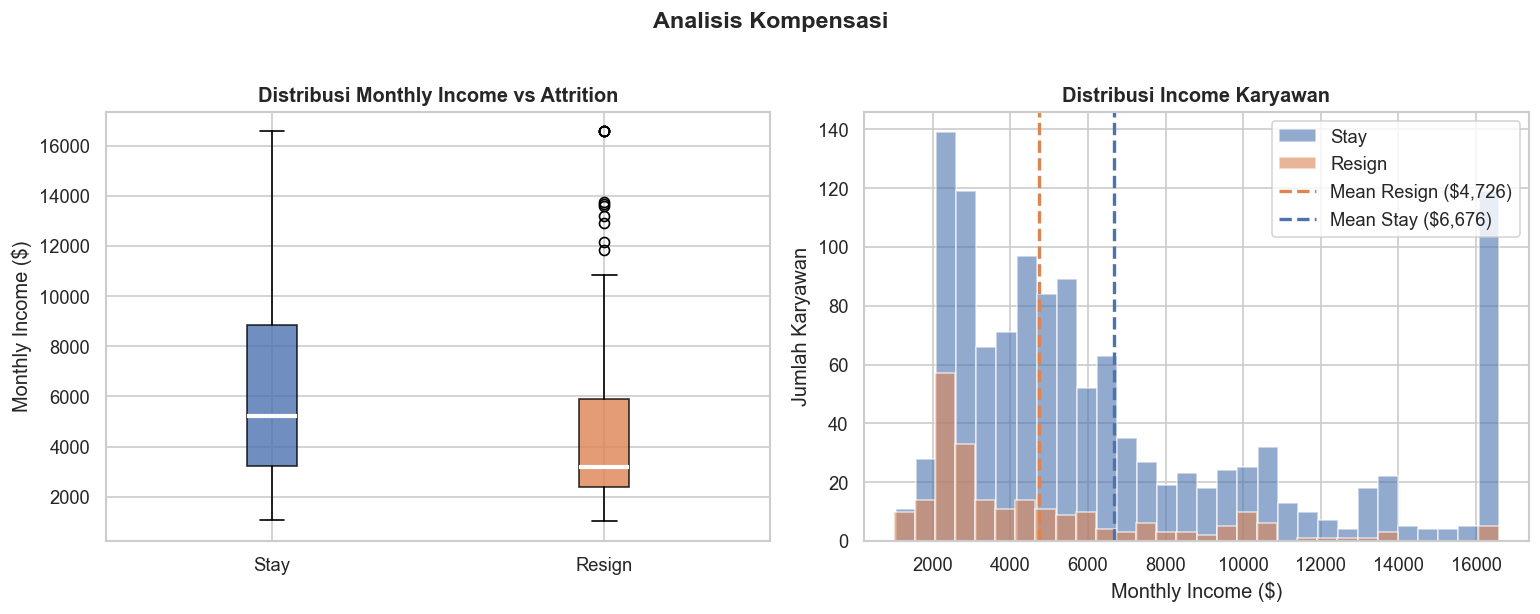


💡 Insight:
   Rata-rata income karyawan yang RESIGN : $4,726
   Rata-rata income karyawan yang STAY   : $6,676
   Karyawan yang resign rata-rata mendapat gaji ~29% lebih rendah — gap yang signifikan.


In [155]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot Income
data_income = [df[df['Attrition']==0]['MonthlyIncome'],
               df[df['Attrition']==1]['MonthlyIncome']]
bp = axes[0].boxplot(data_income, patch_artist=True,
                     medianprops={'color':'white','linewidth':2.5})
for patch, color in zip(bp['boxes'], [ATTRITION_COLORS[0], ATTRITION_COLORS[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_xticklabels(['Stay', 'Resign'])
axes[0].set_title('Distribusi Monthly Income vs Attrition', fontweight='bold')
axes[0].set_ylabel('Monthly Income ($)')

# Histogram Income overlay
for val, label in [(0,'Stay'), (1,'Resign')]:
    axes[1].hist(df[df['Attrition']==val]['MonthlyIncome'],
                 bins=30, alpha=0.6,
                 color=ATTRITION_COLORS[val], label=label, edgecolor='white')
axes[1].axvline(df[df['Attrition']==1]['MonthlyIncome'].mean(),
                color=ATTRITION_COLORS[1], linestyle='--', linewidth=2,
                label=f"Mean Resign (${df[df['Attrition']==1]['MonthlyIncome'].mean():,.0f})")
axes[1].axvline(df[df['Attrition']==0]['MonthlyIncome'].mean(),
                color=ATTRITION_COLORS[0], linestyle='--', linewidth=2,
                label=f"Mean Stay (${df[df['Attrition']==0]['MonthlyIncome'].mean():,.0f})")
axes[1].set_title('Distribusi Income Karyawan', fontweight='bold')
axes[1].set_xlabel('Monthly Income ($)')
axes[1].set_ylabel('Jumlah Karyawan')
axes[1].legend()

plt.suptitle('Analisis Kompensasi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../presentation/eda_06_income.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight:')
print(f"   Rata-rata income karyawan yang RESIGN : ${df[df['Attrition']==1]['MonthlyIncome'].mean():,.0f}")
print(f"   Rata-rata income karyawan yang STAY   : ${df[df['Attrition']==0]['MonthlyIncome'].mean():,.0f}")
print('   Karyawan yang resign rata-rata mendapat gaji ~29% lebih rendah — gap yang signifikan.')


### 6.2 Overall Satisfaction Index & Feature-feature Kepuasan

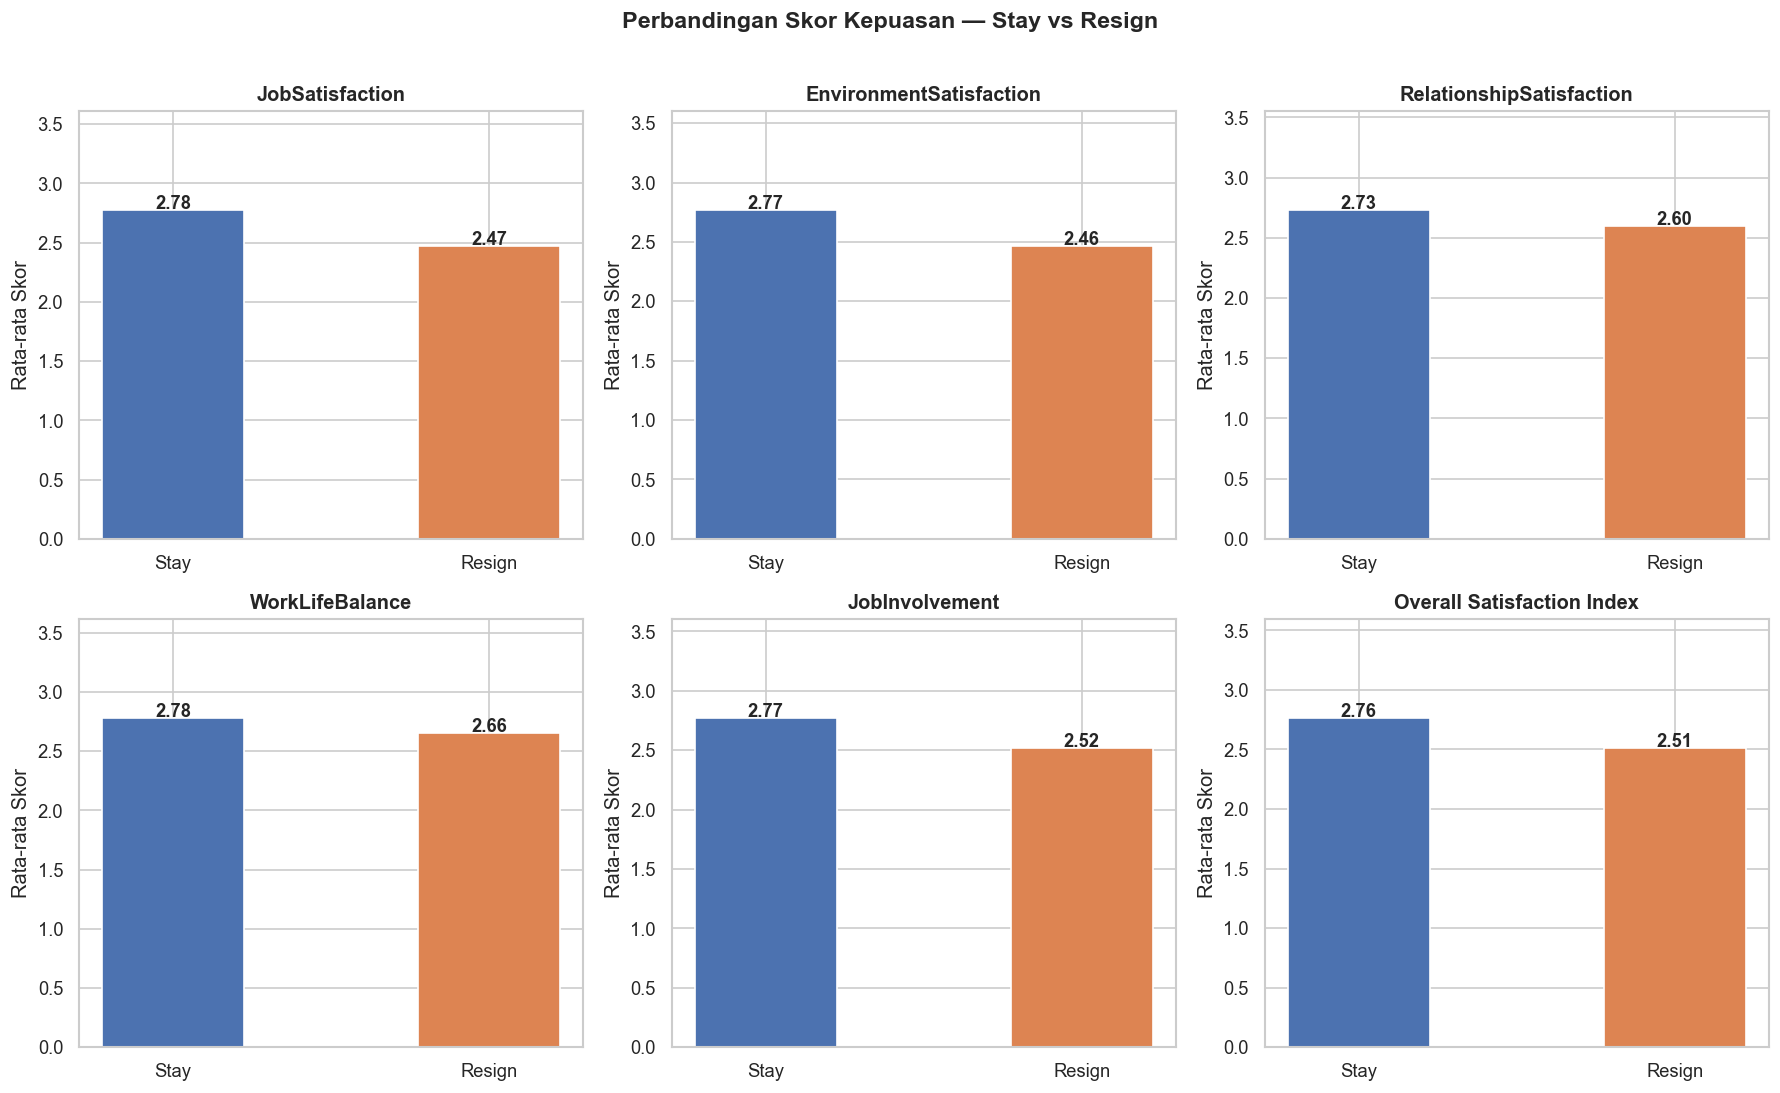


💡 Insight:
   Seluruh dimensi kepuasan rata-rata LEBIH RENDAH pada karyawan yang resign.
   Overall Satisfaction Index merangkum hal ini: Stay=2.76 vs Resign=2.51.
   WorkLifeBalance dan JobInvolvement juga berkontribusi signifikan terhadap attrition.


In [156]:
sat_features = ['JobSatisfaction', 'EnvironmentSatisfaction',
                'RelationshipSatisfaction', 'WorkLifeBalance',
                'JobInvolvement', 'Overall_Satisfaction_Index']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, feat in zip(axes, sat_features):
    means = df.groupby('Attrition')[feat].mean()
    bars = ax.bar(['Stay', 'Resign'], means.values,
                  color=[ATTRITION_COLORS[0], ATTRITION_COLORS[1]],
                  edgecolor='white', width=0.45)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(feat.replace('_', ' '), fontweight='bold')
    ax.set_ylabel('Rata-rata Skor')
    ax.set_ylim(0, means.max() * 1.3)

plt.suptitle('Perbandingan Skor Kepuasan — Stay vs Resign',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../presentation/eda_07_satisfaction.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight:')
print('   Seluruh dimensi kepuasan rata-rata LEBIH RENDAH pada karyawan yang resign.')
print('   Overall Satisfaction Index merangkum hal ini: Stay=2.76 vs Resign=2.51.')
print('   WorkLifeBalance dan JobInvolvement juga berkontribusi signifikan terhadap attrition.')


##  7. Analisis Faktor Karir & Pengalaman

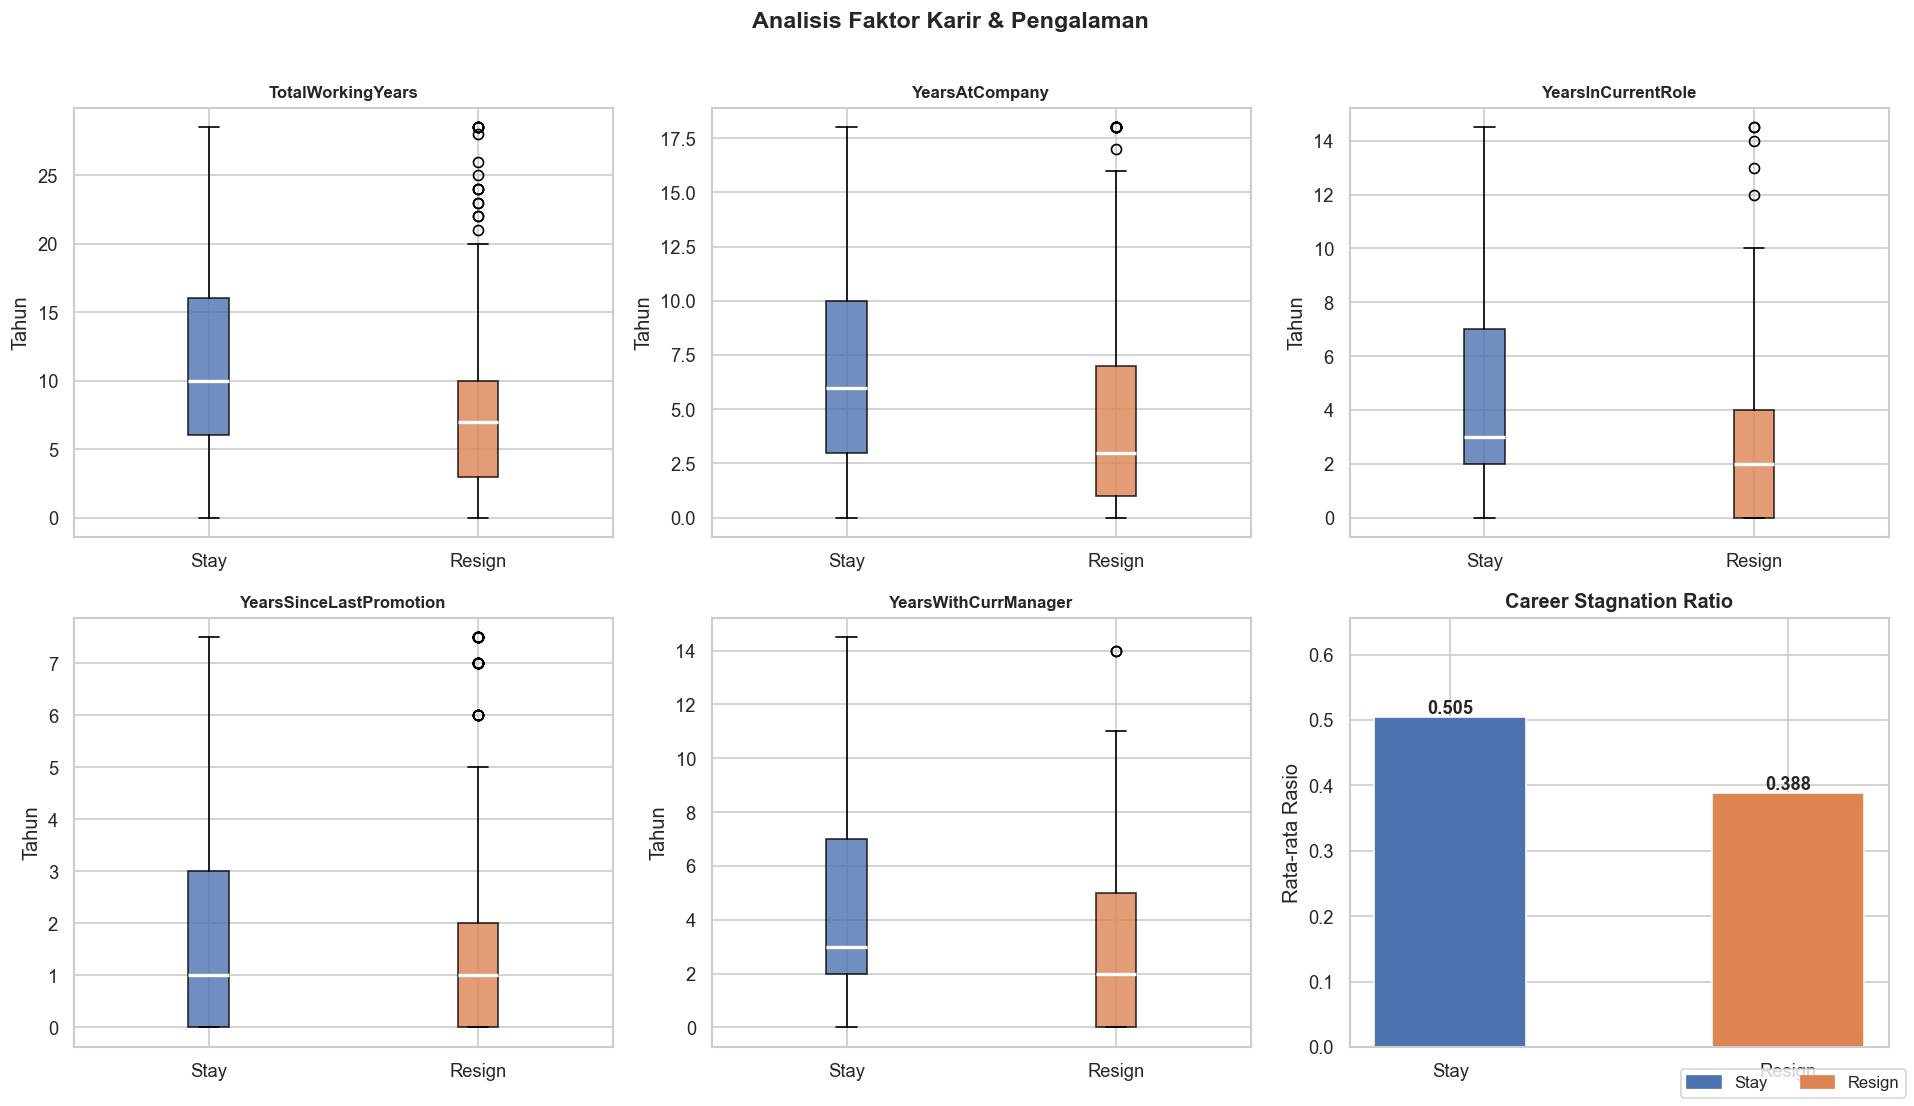


💡 Insight:
   Karyawan yang resign rata-rata memiliki pengalaman kerja lebih sedikit (total working years lebih rendah).
   YearsAtCompany dan YearsInCurrentRole yang rendah berkorelasi kuat dengan attrition.
   Karyawan yang stagnan (lama tidak promosi) cenderung lebih rentan resign.


In [157]:
career_features = ['TotalWorkingYears', 'YearsAtCompany',
                   'YearsInCurrentRole', 'YearsSinceLastPromotion',
                   'YearsWithCurrManager']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, career_features):
    data = [df[df['Attrition']==0][feat].dropna(),
            df[df['Attrition']==1][feat].dropna()]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops={'color':'white','linewidth':2})
    for patch, color in zip(bp['boxes'], [ATTRITION_COLORS[0], ATTRITION_COLORS[1]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(['Stay', 'Resign'])
    ax.set_title(feat.replace('_', ' '), fontweight='bold', fontsize=10)
    ax.set_ylabel('Tahun')

# Career Stagnation Ratio
ax = axes[5]
means_csr = df.groupby('Attrition')['Career_Stagnation_Ratio'].mean()
bars = ax.bar(['Stay', 'Resign'], means_csr.values,
              color=[ATTRITION_COLORS[0], ATTRITION_COLORS[1]],
              edgecolor='white', width=0.45)
for bar, val in zip(bars, means_csr.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Career Stagnation Ratio', fontweight='bold')
ax.set_ylabel('Rata-rata Rasio')
ax.set_ylim(0, means_csr.max() * 1.3)

patch_stay   = mpatches.Patch(color=ATTRITION_COLORS[0], label='Stay')
patch_resign = mpatches.Patch(color=ATTRITION_COLORS[1], label='Resign')
fig.legend(handles=[patch_stay, patch_resign],
           loc='lower right', ncol=2, fontsize=10)

plt.suptitle('Analisis Faktor Karir & Pengalaman',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../presentation/eda_08_career.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight:')
print('   Karyawan yang resign rata-rata memiliki pengalaman kerja lebih sedikit (total working years lebih rendah).')
print('   YearsAtCompany dan YearsInCurrentRole yang rendah berkorelasi kuat dengan attrition.')
print('   Karyawan yang stagnan (lama tidak promosi) cenderung lebih rentan resign.')


### 7.1 Pengaruh Long No Promotion & Is Overworked

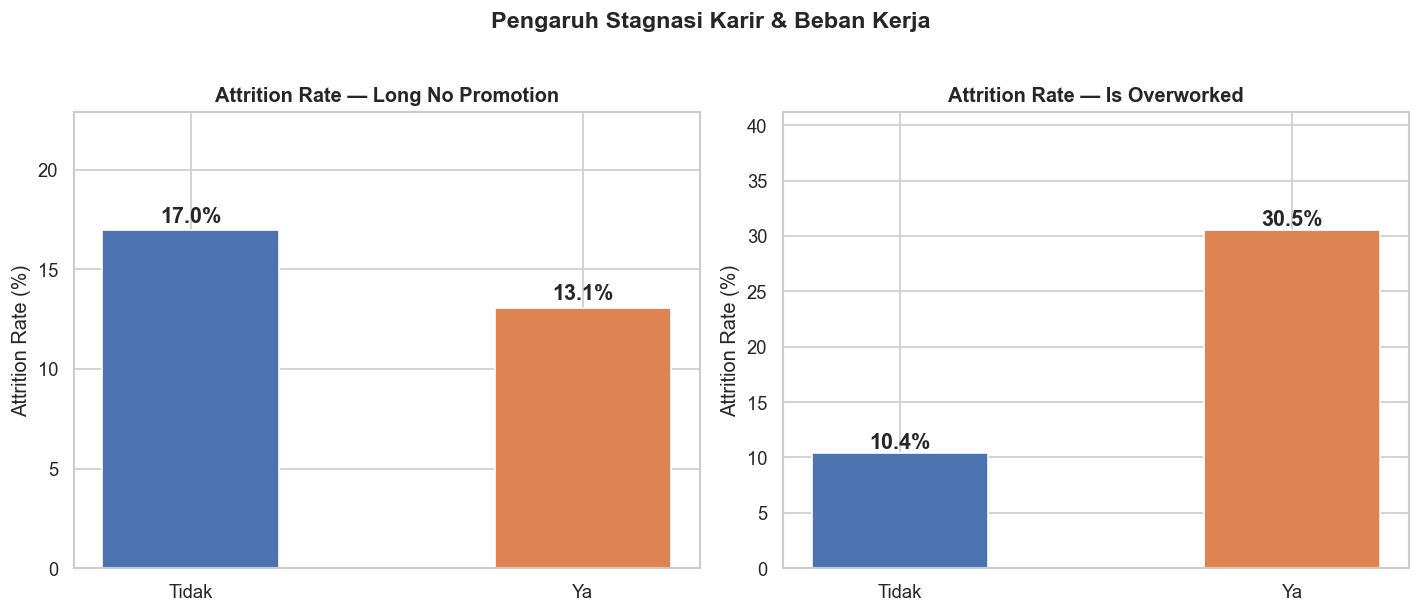


💡 Insight:
   Karyawan yang Is_Overworked memiliki attrition rate 30.5% vs 10.4% (hampir 3x lipat).
   Feature engineering dari Zahra berhasil menangkap pola beban kerja berlebih.


In [158]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feat, title in zip(
    axes,
    ['Long_No_Promotion', 'Is_Overworked'],
    ['Attrition Rate — Long No Promotion', 'Attrition Rate — Is Overworked']
):
    rate = df.groupby(feat)['Attrition'].mean() * 100
    labels = ['Tidak', 'Ya']
    bars = ax.bar(labels, rate.values,
                  color=[PRIMARY, ACCENT], edgecolor='white', width=0.45)
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_ylim(0, rate.max() * 1.35)

plt.suptitle('Pengaruh Stagnasi Karir & Beban Kerja',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../presentation/eda_09_promotion_overwork.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight:')
print('   Karyawan yang Is_Overworked memiliki attrition rate 30.5% vs 10.4% (hampir 3x lipat).')
print('   Feature engineering dari Zahra berhasil menangkap pola beban kerja berlebih.')


## 🔗 8. Analisis Korelasi dengan Target

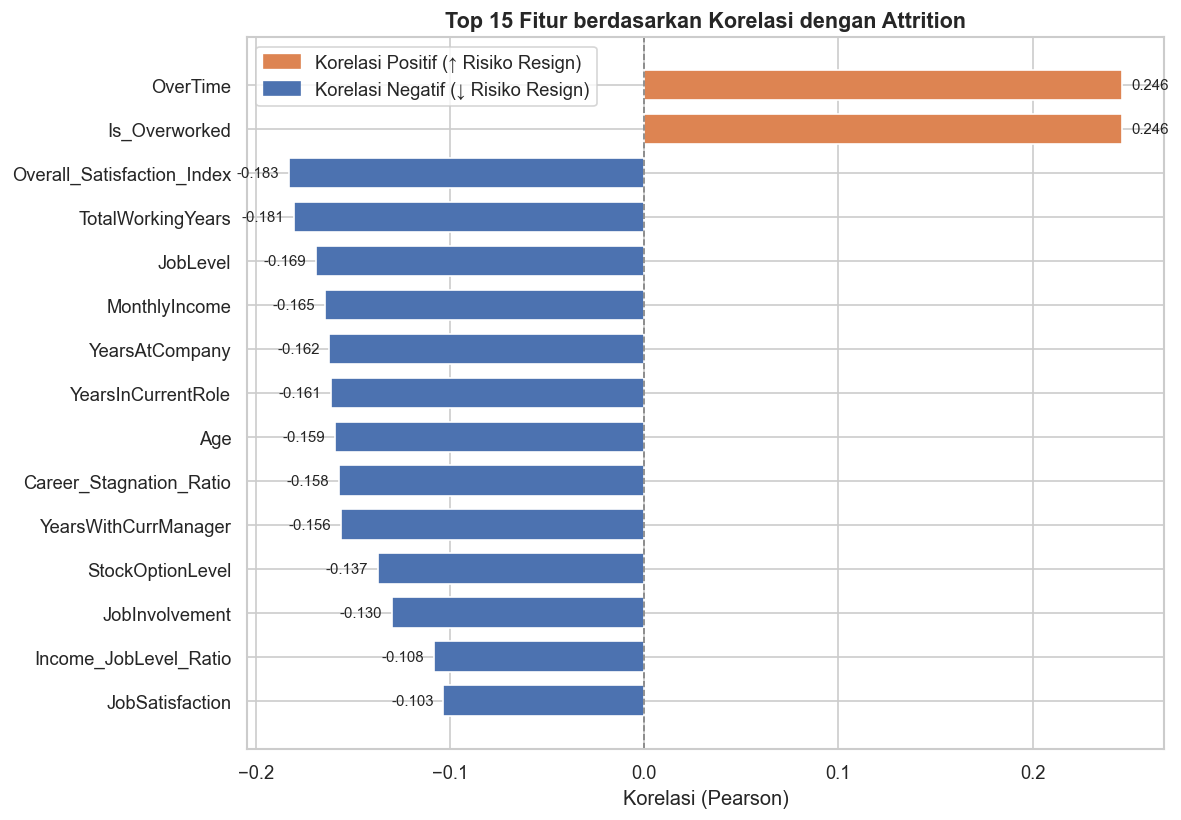


💡 Top faktor pendorong attrition (korelasi positif):
   + OverTime: 0.246
   + Is_Overworked: 0.246

💡 Top faktor penahan karyawan (korelasi negatif):
   - Overall_Satisfaction_Index: -0.183
   - TotalWorkingYears: -0.181
   - JobLevel: -0.169
   - MonthlyIncome: -0.165
   - YearsAtCompany: -0.162


In [159]:
numeric_df = df.select_dtypes(include='number')
corr_target = numeric_df.corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

top_n = 15
top_corr = corr_target.head(top_n)

colors_corr = [ACCENT if v > 0 else PRIMARY for v in top_corr.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_corr.index[::-1], top_corr.values[::-1],
               color=colors_corr[::-1], edgecolor='white', height=0.7)
ax.axvline(0, color='gray', linewidth=1, linestyle='--')
for bar, val in zip(bars, top_corr.values[::-1]):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)
ax.set_title(f'Top {top_n} Fitur berdasarkan Korelasi dengan Attrition',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Korelasi (Pearson)')

patch_pos = mpatches.Patch(color=ACCENT,   label='Korelasi Positif (↑ Risiko Resign)')
patch_neg = mpatches.Patch(color=PRIMARY,  label='Korelasi Negatif (↓ Risiko Resign)')
ax.legend(handles=[patch_pos, patch_neg])

plt.tight_layout()
plt.savefig('../presentation/eda_10_correlation.png', bbox_inches='tight')
plt.show()

print('\n💡 Top faktor pendorong attrition (korelasi positif):')
pos = top_corr[top_corr > 0]
for feat, val in pos.items():
    print(f'   + {feat}: {val:.3f}')

print('\n💡 Top faktor penahan karyawan (korelasi negatif):')
neg = top_corr[top_corr < 0].head(5)
for feat, val in neg.items():
    print(f'   - {feat}: {val:.3f}')


### 8.1 Heatmap Korelasi Antar Fitur Utama

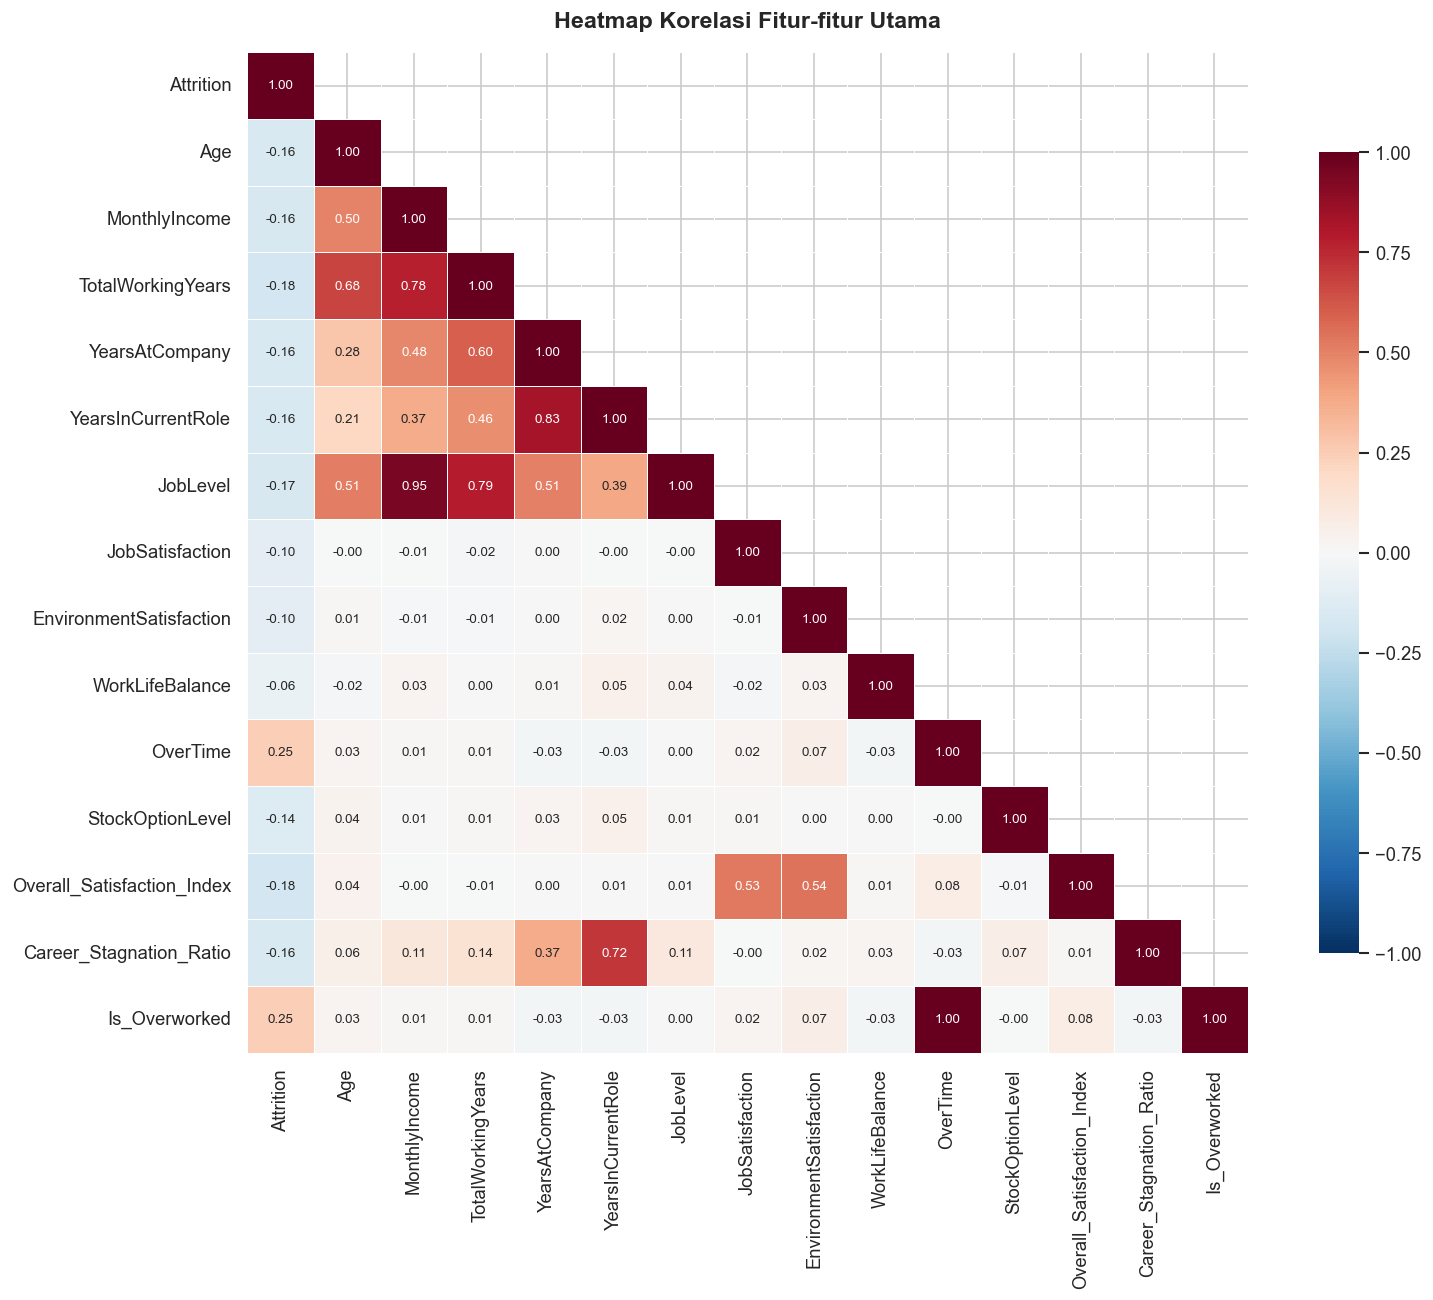

In [160]:
key_features = [
    'Attrition', 'Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'JobLevel', 'JobSatisfaction', 'EnvironmentSatisfaction',
    'WorkLifeBalance', 'OverTime', 'StockOptionLevel', 'Overall_Satisfaction_Index',
    'Career_Stagnation_Ratio', 'Is_Overworked'
]

corr_matrix = df[key_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    mask=mask,
    linewidths=0.5, linecolor='white',
    square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Heatmap Korelasi Fitur-fitur Utama', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../presentation/eda_11_heatmap.png', bbox_inches='tight')
plt.show()


## ✈️ 9. Pengaruh Business Travel

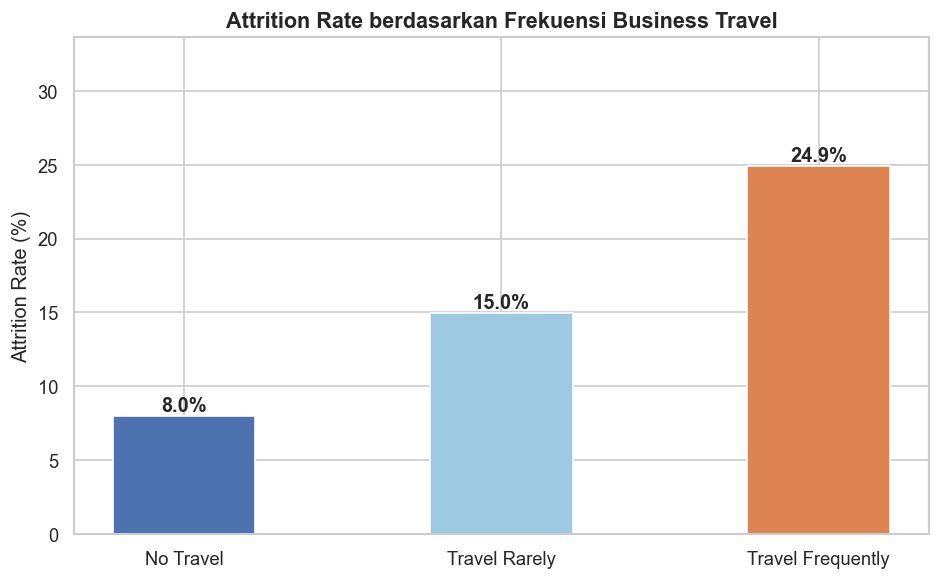


💡 Insight:
   Semakin sering perjalanan bisnis, semakin tinggi risiko attrition.
   Karyawan yang Travel Frequently memiliki attrition rate jauh lebih tinggi.


In [161]:
travel_data = {
    'No Travel': df[(df['BusinessTravel_Travel_Frequently']==False) &
                    (df['BusinessTravel_Travel_Rarely']==False)]['Attrition'].mean()*100,
    'Travel Rarely': df[df['BusinessTravel_Travel_Rarely']==True]['Attrition'].mean()*100,
    'Travel Frequently': df[df['BusinessTravel_Travel_Frequently']==True]['Attrition'].mean()*100
}

colors_travel = [PRIMARY, '#9EC9E2', ACCENT]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(travel_data.keys(), travel_data.values(),
              color=colors_travel, edgecolor='white', width=0.45)
for bar, val in zip(bars, travel_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Attrition Rate berdasarkan Frekuensi Business Travel',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, max(travel_data.values()) * 1.35)

plt.tight_layout()
plt.savefig('../presentation/eda_12_business_travel.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight:')
print('   Semakin sering perjalanan bisnis, semakin tinggi risiko attrition.')
print('   Karyawan yang Travel Frequently memiliki attrition rate jauh lebih tinggi.')


## 📝 10. Ringkasan Insight EDA

### 🔑 Faktor-faktor Utama yang Mendorong Attrition

| # | Faktor | Temuan |
|---|--------|--------|
| 1 | **OverTime / Is_Overworked** | Karyawan yang lembur resign ~3x lebih banyak (30.5% vs 10.4%) |
| 2 | **Job Level** | Entry-level (Level 1) paling rentan: attrition 26.3% |
| 3 | **Job Role** | Sales Representative tertinggi (39.8%), Research Director terendah (2.5%) |
| 4 | **Monthly Income** | Karyawan resign berpenghasilan rata-rata 29% lebih rendah |
| 5 | **Status Pernikahan** | Single: 25.5% vs menikah: 11.7% |
| 6 | **Generasi** | Millennial paling rentan (20.2%) |
| 7 | **Overall Satisfaction** | Stay: 2.76 vs Resign: 2.51 |
| 8 | **Departemen** | Sales paling rentan (20.6%), R&D paling stabil (13.8%) |
| 9 | **Pengalaman Kerja** | Karyawan baru dan karyawan dengan tahun jabatan rendah lebih berisiko |
| 10 | **Business Travel** | Sering perjalanan bisnis meningkatkan risiko resign |

### 💡 Rekomendasi untuk Perusahaan

1. **Batasi OverTime** — monitoring beban kerja dan rekrut lebih banyak staf jika diperlukan
2. **Program retensi entry-level** — mentoring, career path yang jelas, dan kompensasi kompetitif
3. **Perhatikan Sales Representative** — role dengan tekanan tinggi butuh support ekstra
4. **Review kompensasi** — gap gaji yang besar menjadi pemicu utama turnover
5. **Program untuk karyawan muda/single** — employee engagement, benefit, dan keseimbangan hidup

### 🤖 Implikasi untuk Modeling (Hafizatul)

- Dataset imbalanced (~16% resign) → pertimbangkan SMOTE atau `class_weight='balanced'`
- Fitur paling prediktif: `OverTime`, `Is_Overworked`, `Overall_Satisfaction_Index`, `TotalWorkingYears`, `JobLevel`, `MonthlyIncome`
- Feature engineering dari Zahra (`Career_Stagnation_Ratio`, `Is_Overworked`, `Overall_Satisfaction_Index`) terbukti memiliki korelasi signifikan dengan target


In [162]:
print('✅ EDA selesai!')
print('📊 Semua visualisasi tersimpan di folder ../presentation/')
print()
print('File yang dihasilkan:')
import os, glob
pngs = sorted(glob.glob('../presentation/eda_*.png'))
for f in pngs:
    print(f'  📈 {os.path.basename(f)}')


✅ EDA selesai!
📊 Semua visualisasi tersimpan di folder ../presentation/

File yang dihasilkan:
  📈 eda_01_target_distribution.png
  📈 eda_02_age_generation.png
  📈 eda_03_gender_marital.png
  📈 eda_04_dept_jobrole.png
  📈 eda_05_joblevel_overtime.png
  📈 eda_06_income.png
  📈 eda_07_satisfaction.png
  📈 eda_08_career.png
  📈 eda_09_promotion_overwork.png
  📈 eda_10_correlation.png
  📈 eda_11_heatmap.png
  📈 eda_12_business_travel.png


# Machine Learning — Employee Attrition Risk Prediction
Dikerjakan oleh: Hafizatul Khairani
**Tanggung jawab:**
- ✅ Pemilihan model
- ✅ Training model
- ✅ Evaluasi model
- ✅ Hyperparameter Tuning

**Import Libarary**

In [163]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              roc_curve, precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print('✅ Library ML berhasil diimport')

✅ Library ML berhasil diimport


**Load Data**

In [164]:
X = pd.read_csv('../data/X_preprocessed.csv')
y = pd.read_csv('../data/y_target.csv').squeeze()

print(f'✅ Shape X: {X.shape}')
print(f'✅ Shape y: {y.shape}')
print(f'\nDistribusi kelas:')
print(y.value_counts())
print(f'  → Class 0 (Stay)  : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'  → Class 1 (Resign): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')



✅ Shape X: (1470, 53)
✅ Shape y: (1470,)

Distribusi kelas:
Attrition
0    1233
1     237
Name: count, dtype: int64
  → Class 0 (Stay)  : 1233 (83.9%)
  → Class 1 (Resign): 237 (16.1%)


**Train-Test Split**

In [165]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train size : {X_train.shape}')
print(f'✅ Test size  : {X_test.shape}')
print(f'\nDistribusi y_train:')
print(y_train.value_counts())
print(f'  → Stay  : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)')
print(f'  → Resign: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'\nDistribusi y_test:')
print(y_test.value_counts())

✅ Train size : (1176, 53)
✅ Test size  : (294, 53)

Distribusi y_train:
Attrition
0    986
1    190
Name: count, dtype: int64
  → Stay  : 986 (83.8%)
  → Resign: 190 (16.2%)

Distribusi y_test:
Attrition
0    247
1     47
Name: count, dtype: int64


**Handle Class Imbalance dengan SMOTE**

=== HASIL SMOTE ===
Sebelum SMOTE:
  Stay  : 986
  Resign: 190

Setelah SMOTE:
  Stay  : 986
  Resign: 986

✅ Shape X_train setelah SMOTE: (1972, 53)


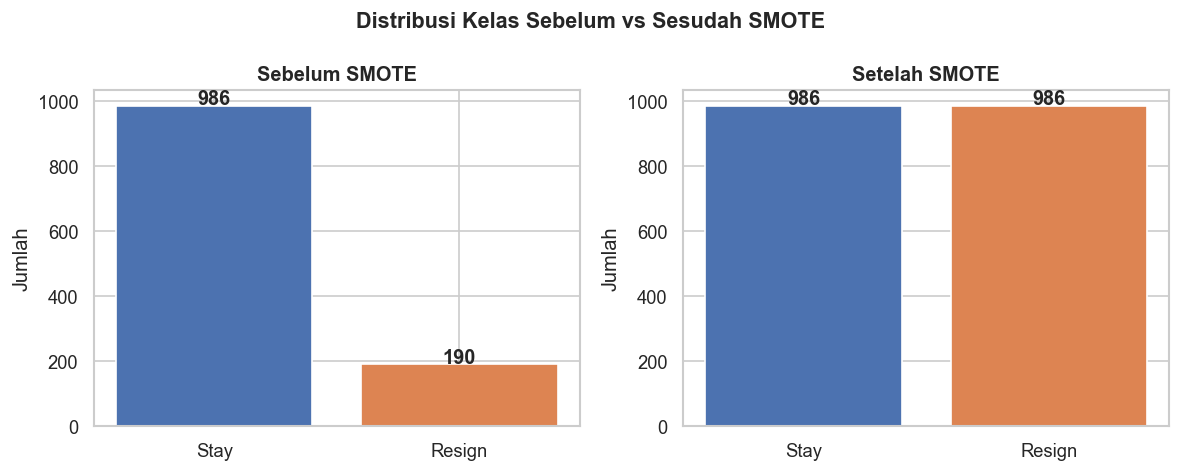

In [166]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('=== HASIL SMOTE ===')
print(f'Sebelum SMOTE:')
print(f'  Stay  : {(y_train==0).sum()}')
print(f'  Resign: {(y_train==1).sum()}')
print(f'\nSetelah SMOTE:')
print(f'  Stay  : {(pd.Series(y_train_sm)==0).sum()}')
print(f'  Resign: {(pd.Series(y_train_sm)==1).sum()}')
print(f'\n✅ Shape X_train setelah SMOTE: {X_train_sm.shape}')

# Visualisasi sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Stay', 'Resign'], [y_train.value_counts()[0], y_train.value_counts()[1]],
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Sebelum SMOTE', fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate([y_train.value_counts()[0], y_train.value_counts()[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

sm_counts = pd.Series(y_train_sm).value_counts()
axes[1].bar(['Stay', 'Resign'], [sm_counts[0], sm_counts[1]],
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[1].set_title('Setelah SMOTE', fontweight='bold')
axes[1].set_ylabel('Jumlah')
for i, v in enumerate([sm_counts[0], sm_counts[1]]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('Distribusi Kelas Sebelum vs Sesudah SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../presentation/ml_01_smote.png', bbox_inches='tight')
plt.show()

**Training Model**

In [167]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : xgb.XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4),
    }
    print(f'✅ {name} selesai ditraining')

results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
print('\n=== HASIL EVALUASI SEMUA MODEL ===')
print(results_df)

✅ Logistic Regression selesai ditraining
✅ Decision Tree selesai ditraining
✅ Random Forest selesai ditraining
✅ XGBoost selesai ditraining

=== HASIL EVALUASI SEMUA MODEL ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.8435     0.5135  0.4043    0.4524   0.8022
XGBoost                0.8673     0.7000  0.2979    0.4179   0.7655
Decision Tree          0.7279     0.2676  0.4043    0.3220   0.5969
Random Forest          0.8299     0.4348  0.2128    0.2857   0.7391


**Visualisasi Perbandingan Model**

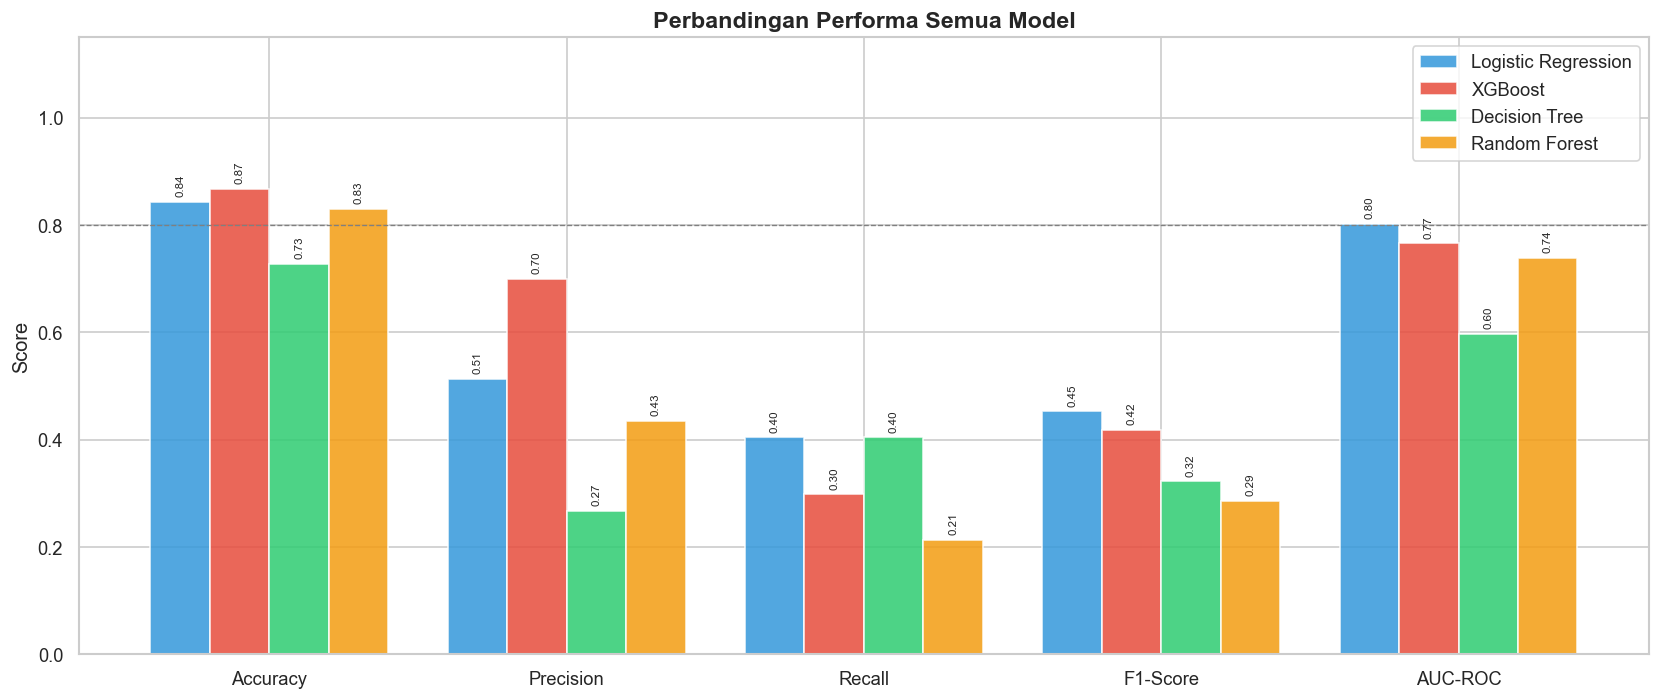

In [168]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colors_model = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
x = range(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar([xi + i*width for xi in x], vals, width=width,
           label=name, color=colors_model[i], alpha=0.85)

ax.set_xticks([xi + width*1.5 for xi in x])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Semua Model', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(0.8, linestyle='--', color='gray', linewidth=0.8, label='Threshold 0.8')

for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    for j, (xi, v) in enumerate(zip(x, vals)):
        ax.text(xi + i*width, v + 0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout()
plt.savefig('../presentation/ml_02_model_comparison.png', bbox_inches='tight')
plt.show()

**Model Terbaik & Confusion Matrix**

Model Terbaik: Logistic Regression
   Accuracy  : 0.8435
   Precision : 0.5135
   Recall    : 0.4043
   F1-Score  : 0.4524
   AUC-ROC   : 0.8022

=== CLASSIFICATION REPORT (Logistic Regression) ===
              precision    recall  f1-score   support

        Stay       0.89      0.93      0.91       247
      Resign       0.51      0.40      0.45        47

    accuracy                           0.84       294
   macro avg       0.70      0.67      0.68       294
weighted avg       0.83      0.84      0.84       294



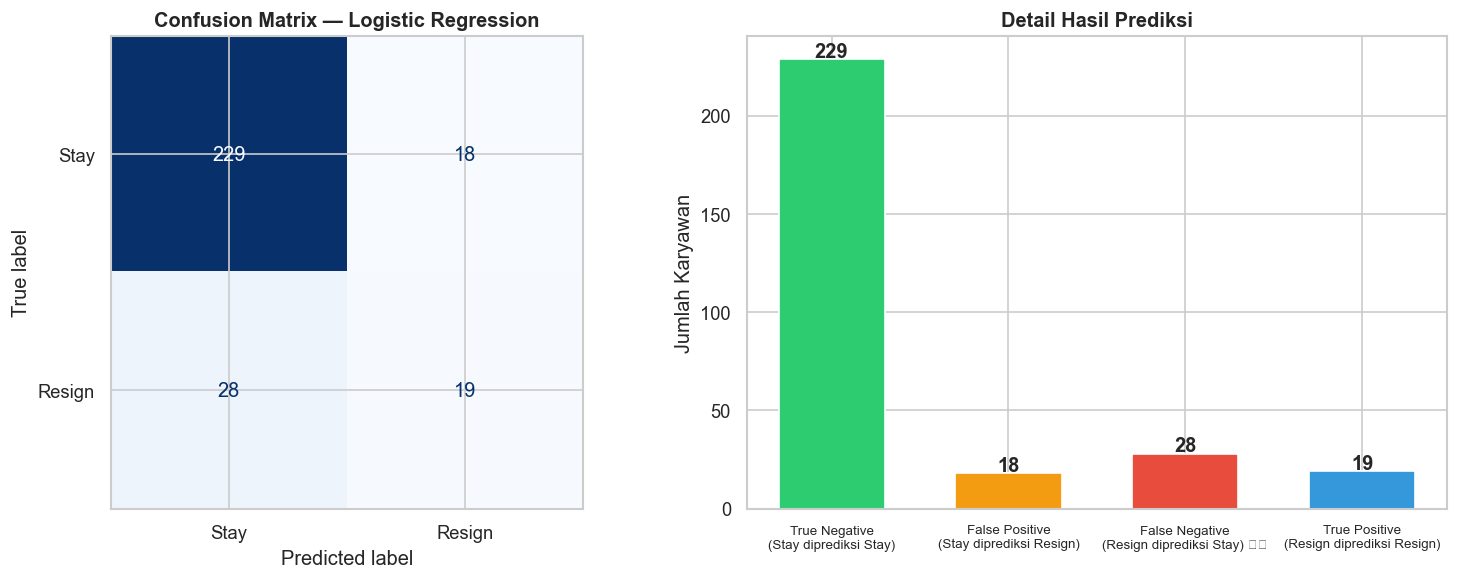


📊 Ringkasan Confusion Matrix:
   ✅ Benar diprediksi Stay   (TN): 229
   ⚠️  Salah diprediksi Resign (FP): 18 (false alarm)
   ❌ Gagal deteksi Resign    (FN): 28 (missed!)
   ✅ Benar diprediksi Resign (TP): 19


In [169]:
best_model_name = results_df['F1-Score'].idxmax()
best_model = models[best_model_name]

print(f'Model Terbaik: {best_model_name}')
print(f'   Accuracy  : {results_df.loc[best_model_name, "Accuracy"]}')
print(f'   Precision : {results_df.loc[best_model_name, "Precision"]}')
print(f'   Recall    : {results_df.loc[best_model_name, "Recall"]}')
print(f'   F1-Score  : {results_df.loc[best_model_name, "F1-Score"]}')
print(f'   AUC-ROC   : {results_df.loc[best_model_name, "AUC-ROC"]}')

y_pred_best = best_model.predict(X_test)

print(f'\n=== CLASSIFICATION REPORT ({best_model_name}) ===')
print(classification_report(y_test, y_pred_best, target_names=['Stay', 'Resign']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Resign'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')

# Breakdown detail
categories = ['True Negative\n(Stay diprediksi Stay)',
              'False Positive\n(Stay diprediksi Resign)',
              'False Negative\n(Resign diprediksi Stay) ⚠️',
              'True Positive\n(Resign diprediksi Resign)']
values = [tn, fp, fn, tp]
colors_cm = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']

bars = axes[1].bar(range(4), values, color=colors_cm, edgecolor='white', width=0.6)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(categories, fontsize=8)
axes[1].set_ylabel('Jumlah Karyawan')
axes[1].set_title('Detail Hasil Prediksi', fontweight='bold')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, str(val),
                 ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../presentation/ml_03_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f'\n📊 Ringkasan Confusion Matrix:')
print(f'   ✅ Benar diprediksi Stay   (TN): {tn}')
print(f'   ⚠️  Salah diprediksi Resign (FP): {fp} (false alarm)')
print(f'   ❌ Gagal deteksi Resign    (FN): {fn} (missed!)')
print(f'   ✅ Benar diprediksi Resign (TP): {tp}')

**Cross Validation**

=== CROSS VALIDATION (Logistic Regression) ===
F1-Score per fold : [np.float64(0.9138), np.float64(0.9044), np.float64(0.8609), np.float64(0.8822), np.float64(0.9096)]
Mean F1-Score     : 0.8942
Std               : 0.0199
Min               : 0.8609
Max               : 0.9138


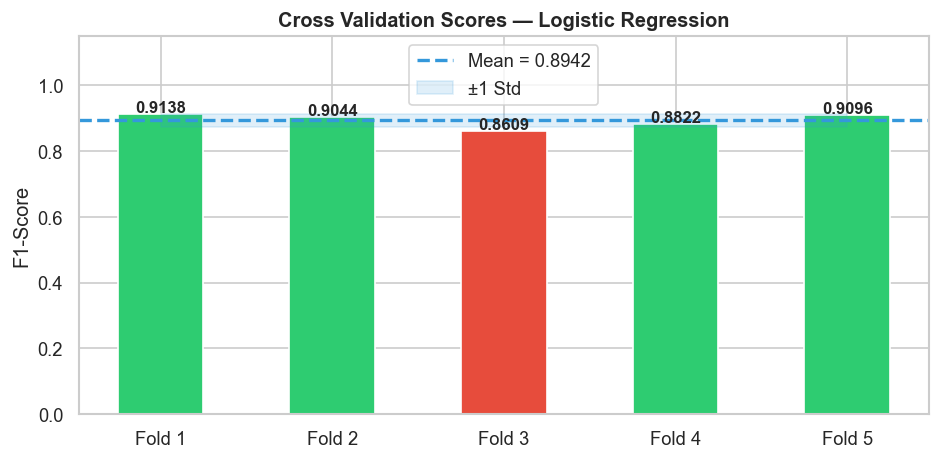


✅ Model stabil — variasi antar fold kecil (std < 0.05)


In [170]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train_sm, y_train_sm,
                            cv=skf, scoring='f1')

print(f'=== CROSS VALIDATION ({best_model_name}) ===')
print(f'F1-Score per fold : {[round(s, 4) for s in cv_scores]}')
print(f'Mean F1-Score     : {cv_scores.mean():.4f}')
print(f'Std               : {cv_scores.std():.4f}')
print(f'Min               : {cv_scores.min():.4f}')
print(f'Max               : {cv_scores.max():.4f}')

# Visualisasi CV scores
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
colors_cv = ['#e74c3c' if s < cv_scores.mean() - cv_scores.std()
             else '#2ecc71' for s in cv_scores]
bars = ax.bar(folds, cv_scores, color=colors_cv, edgecolor='white', width=0.5)
ax.axhline(cv_scores.mean(), color='#3498db', linestyle='--', linewidth=2,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.fill_between(range(5),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color='#3498db', label='±1 Std')
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1-Score')
ax.set_title(f'Cross Validation Scores — {best_model_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../presentation/ml_05_cross_validation.png', bbox_inches='tight')
plt.show()

if cv_scores.std() < 0.05:
    print('\n✅ Model stabil — variasi antar fold kecil (std < 0.05)')
elif cv_scores.std() < 0.10:
    print('\n⚠️  Model cukup stabil — variasi dalam batas wajar (std < 0.10)')
else:
    print('\n❌ Model kurang stabil — variasi antar fold besar')
    print('   Kemungkinan karena dataset kecil atau distribusi SMOTE tidak merata')

**ROC Curve & Precision-Recall Curve**

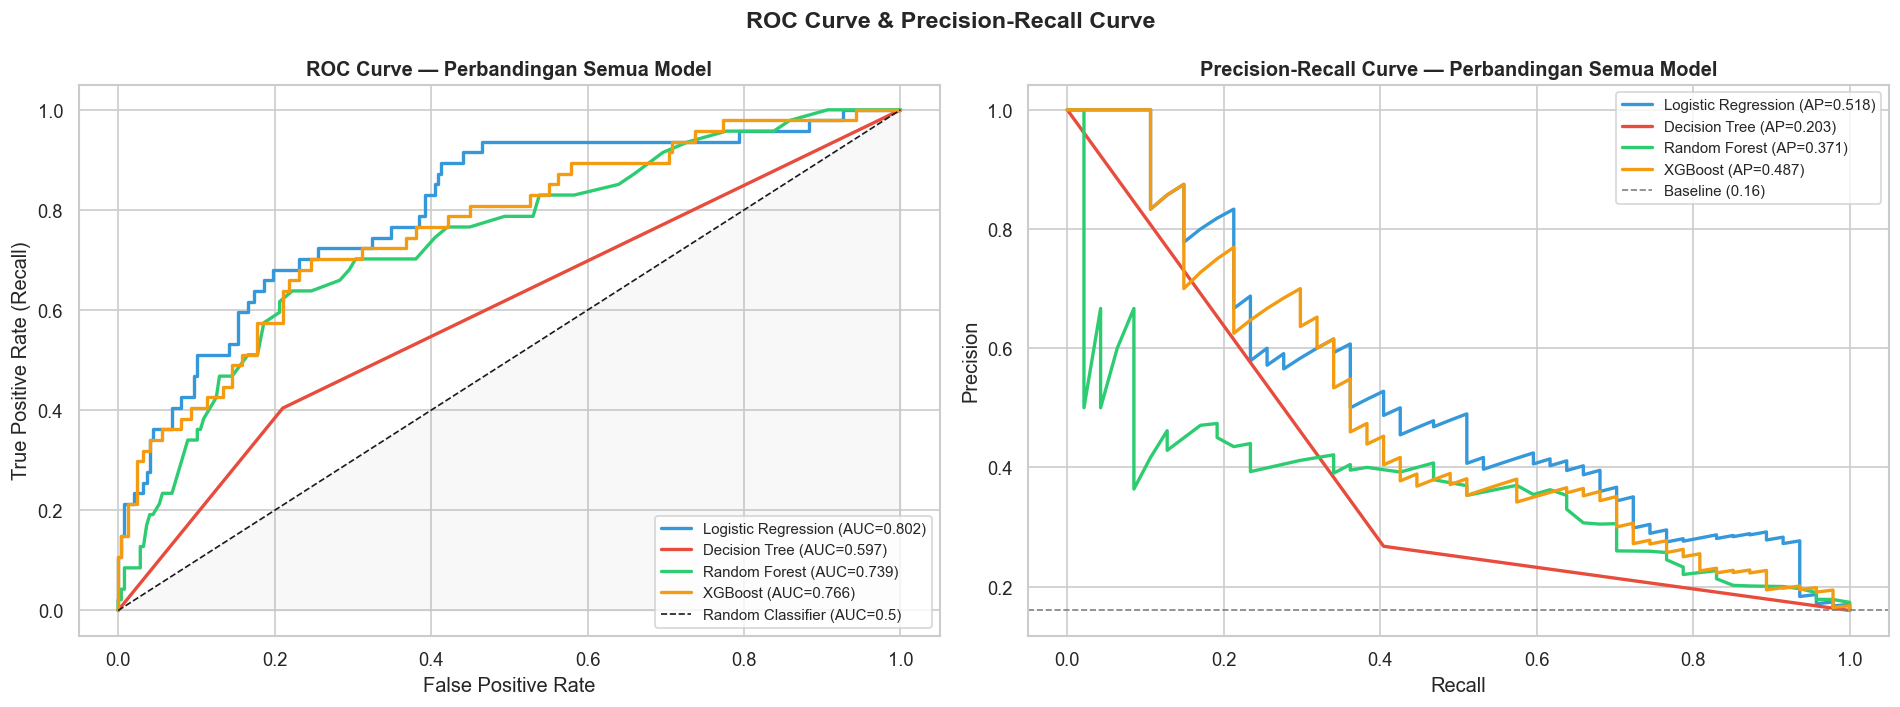

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_model = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# ROC Curve
for (name, model), color in zip(models.items(), colors_model):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                 color=color, linewidth=2)

axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier (AUC=0.5)')
axes[0].fill_between([0,1], [0,1], alpha=0.05, color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve — Perbandingan Semua Model', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

# Precision-Recall Curve
for (name, model), color in zip(models.items(), colors_model):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(recall, precision,
                 label=f'{name} (AP={ap:.3f})',
                 color=color, linewidth=2)

baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1,
                label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Perbandingan Semua Model', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('ROC Curve & Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../presentation/ml_06_roc_pr_curve.png', bbox_inches='tight')
plt.show()

**Threshold Optimization**

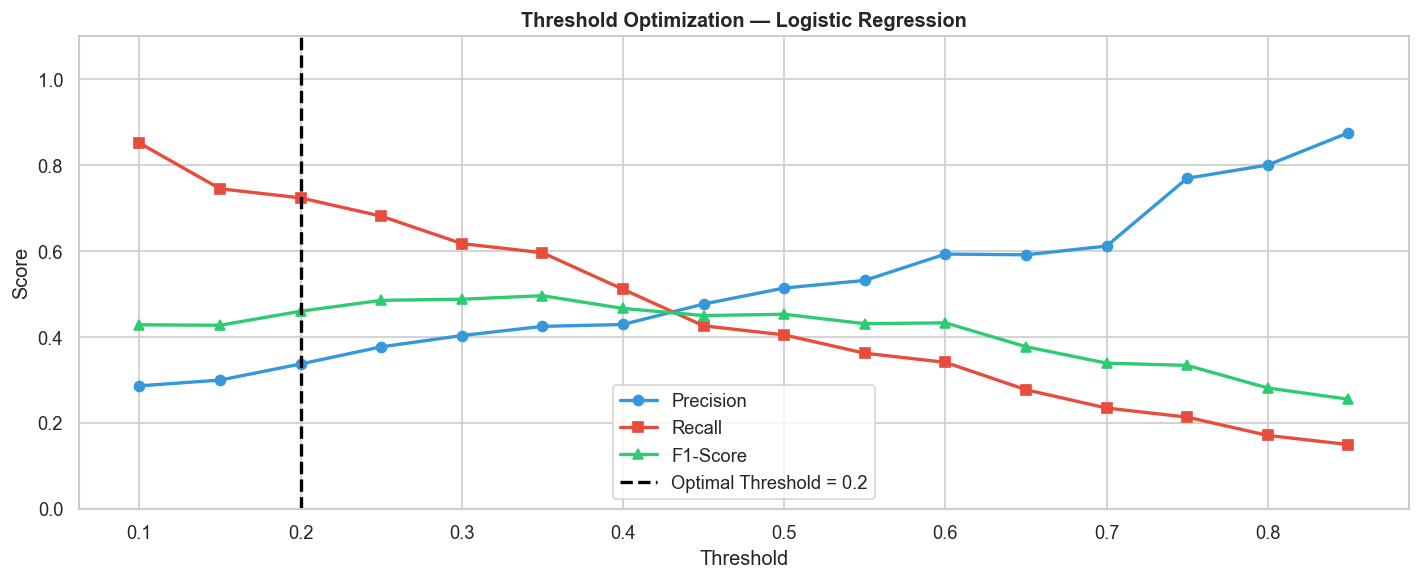

=== OPTIMAL THRESHOLD ===
Threshold : 0.2
Precision : 0.3366
Recall    : 0.7234
F1-Score  : 0.4595

→ Dengan threshold 0.2, model lebih sensitif
  mendeteksi karyawan berisiko resign (Recall lebih tinggi)


In [172]:
y_prob_best = best_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

threshold_results = []
for thresh in thresholds:
    y_pred_t = (y_prob_best >= thresh).astype(int)
    threshold_results.append({
        'Threshold' : round(thresh, 2),
        'Precision' : round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'Accuracy'  : round(accuracy_score(y_test, y_pred_t), 4),
    })

thresh_df = pd.DataFrame(threshold_results)

# Pilih threshold optimal
recall_filter = thresh_df[thresh_df['Recall'] >= 0.70]
if len(recall_filter) == 0:
    best_thresh_row = thresh_df.sort_values('F1-Score', ascending=False).iloc[0]
else:
    best_thresh_row = recall_filter.sort_values('F1-Score', ascending=False).iloc[0]

OPTIMAL_THRESHOLD = best_thresh_row['Threshold']

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'],
        marker='o', label='Precision', color='#3498db', linewidth=2)
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],
        marker='s', label='Recall', color='#e74c3c', linewidth=2)
ax.plot(thresh_df['Threshold'], thresh_df['F1-Score'],
        marker='^', label='F1-Score', color='#2ecc71', linewidth=2)
ax.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--', linewidth=2,
           label=f'Optimal Threshold = {OPTIMAL_THRESHOLD}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Optimization — {best_model_name}', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('../presentation/ml_07_threshold.png', bbox_inches='tight')
plt.show()

print(f'=== OPTIMAL THRESHOLD ===')
print(f'Threshold : {best_thresh_row["Threshold"]}')
print(f'Precision : {best_thresh_row["Precision"]}')
print(f'Recall    : {best_thresh_row["Recall"]}')
print(f'F1-Score  : {best_thresh_row["F1-Score"]}')
print(f'\n→ Dengan threshold {OPTIMAL_THRESHOLD}, model lebih sensitif')
print(f'  mendeteksi karyawan berisiko resign (Recall lebih tinggi)')

**Feature Importance & Model Interpretability**

🔍 Menghitung Feature Importance...


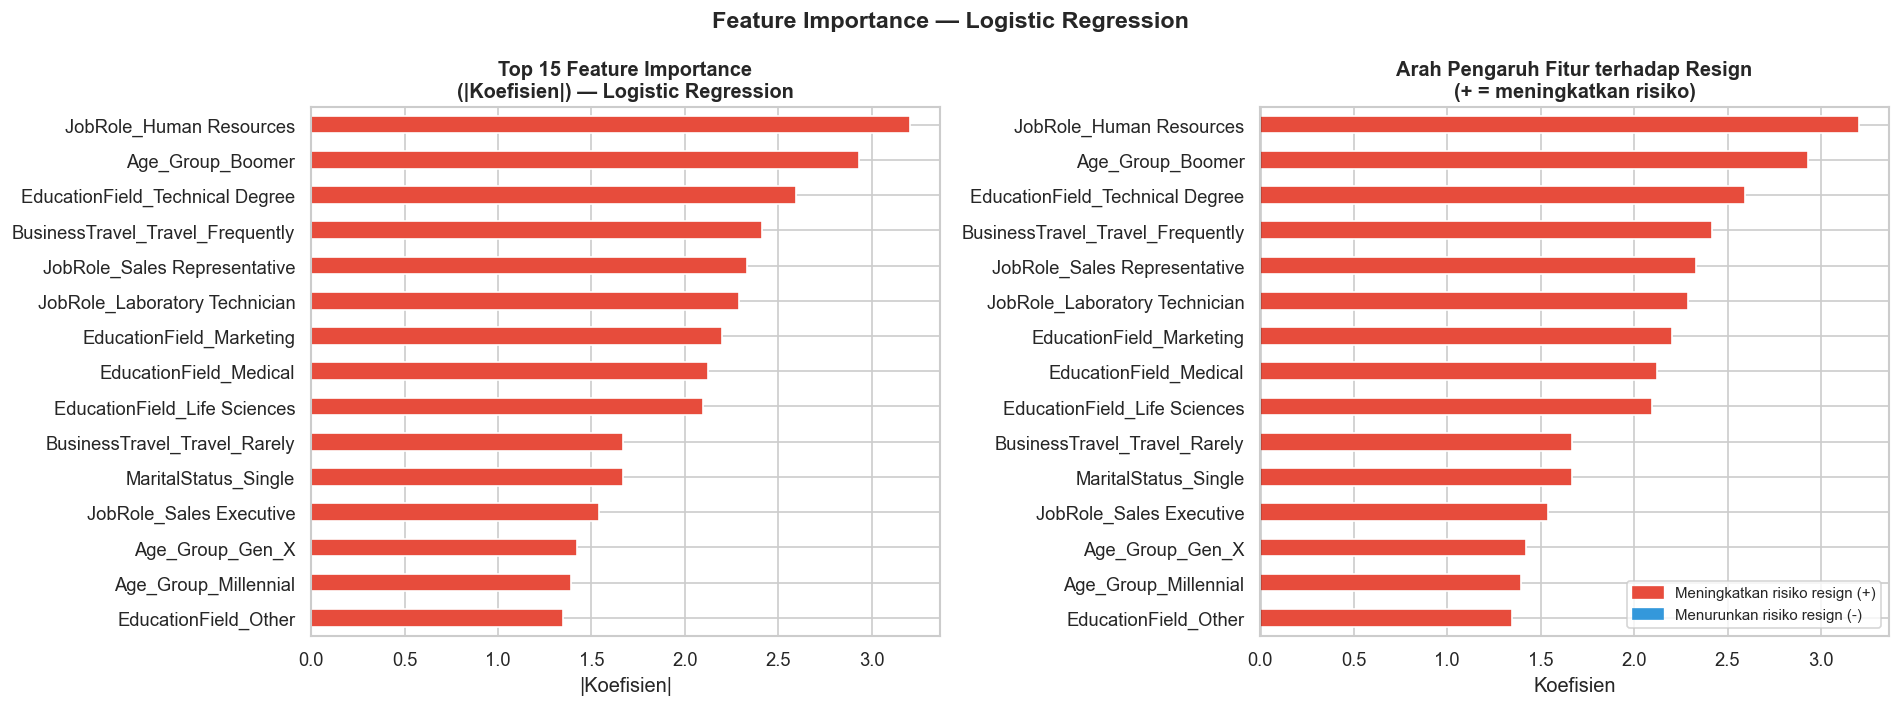


🔍 Top 10 Fitur Paling Berpengaruh:
   JobRole_Human Resources            : +3.2026 (↑ Meningkatkan resign)
   Age_Group_Boomer                   : +2.9326 (↑ Meningkatkan resign)
   EducationField_Technical Degree    : +2.5929 (↑ Meningkatkan resign)
   BusinessTravel_Travel_Frequently   : +2.4147 (↑ Meningkatkan resign)
   JobRole_Sales Representative       : +2.3323 (↑ Meningkatkan resign)
   JobRole_Laboratory Technician      : +2.2910 (↑ Meningkatkan resign)
   EducationField_Marketing           : +2.2003 (↑ Meningkatkan resign)
   EducationField_Medical             : +2.1222 (↑ Meningkatkan resign)
   EducationField_Life Sciences       : +2.0955 (↑ Meningkatkan resign)
   BusinessTravel_Travel_Rarely       : +1.6666 (↑ Meningkatkan resign)

✅ Feature importance selesai! (Model: Logistic Regression)


In [173]:
import shap

print('🔍 Menghitung Feature Importance...')

X_test_df = pd.DataFrame(X_test, columns=X.columns)
X_train_df = pd.DataFrame(X_train_sm, columns=X.columns)

if isinstance(best_model, (RandomForestClassifier, DecisionTreeClassifier)):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_df)
    sv = np.array(shap_values[1] if isinstance(shap_values, list) else shap_values, dtype=float)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_test_df, plot_type='bar', max_display=15, show=False)
    plt.title(f'SHAP Feature Importance — {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../presentation/ml_08_shap_bar.png', bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_test_df, max_display=15, show=False)
    plt.title('SHAP Beeswarm — Dampak Fitur terhadap Prediksi Resign', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../presentation/ml_09_shap_beeswarm.png', bbox_inches='tight')
    plt.show()

elif isinstance(best_model, xgb.XGBClassifier):
    explainer = shap.TreeExplainer(best_model)
    sv = np.array(explainer.shap_values(X_test_df), dtype=float)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_test_df, plot_type='bar', max_display=15, show=False)
    plt.title(f'SHAP Feature Importance — {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../presentation/ml_08_shap_bar.png', bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_test_df, max_display=15, show=False)
    plt.title('SHAP Beeswarm — Dampak Fitur terhadap Prediksi Resign', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../presentation/ml_09_shap_beeswarm.png', bbox_inches='tight')
    plt.show()

elif isinstance(best_model, LogisticRegression):
    # Logistic Regression → pakai koefisien (lebih akurat dari SHAP untuk model linear)
    coef = pd.Series(best_model.coef_[0], index=X.columns)
    top15_abs = coef.abs().sort_values(ascending=False).head(15)
    top15_val = coef[top15_abs.index]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar koefisien absolut
    colors_bar = ['#e74c3c' if top15_val[feat] > 0 else '#3498db'
                  for feat in top15_abs.index]
    top15_abs.sort_values().plot(kind='barh', ax=axes[0], color=colors_bar[::-1])
    axes[0].set_title(f'Top 15 Feature Importance\n(|Koefisien|) — {best_model_name}',
                      fontweight='bold')
    axes[0].set_xlabel('|Koefisien|')

    # Bar koefisien dengan arah (+/-)
    colors_dir = ['#e74c3c' if v > 0 else '#3498db' for v in top15_val.sort_values().values]
    top15_val.sort_values().plot(kind='barh', ax=axes[1], color=colors_dir)
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title(f'Arah Pengaruh Fitur terhadap Resign\n(+ = meningkatkan risiko)',
                      fontweight='bold')
    axes[1].set_xlabel('Koefisien')

    import matplotlib.patches as mpatches
    patch_pos = mpatches.Patch(color='#e74c3c', label='Meningkatkan risiko resign (+)')
    patch_neg = mpatches.Patch(color='#3498db', label='Menurunkan risiko resign (-)')
    axes[1].legend(handles=[patch_pos, patch_neg], fontsize=9)

    plt.suptitle('Feature Importance — Logistic Regression', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../presentation/ml_08_shap_bar.png', bbox_inches='tight')
    plt.show()

    print('\n🔍 Top 10 Fitur Paling Berpengaruh:')
    for feat in top15_abs.head(10).index:
        arah = '↑ Meningkatkan resign' if coef[feat] > 0 else '↓ Menurunkan resign'
        print(f'   {feat:<35}: {coef[feat]:+.4f} ({arah})')

print(f'\n✅ Feature importance selesai! (Model: {best_model_name})')

**Feature Selection**

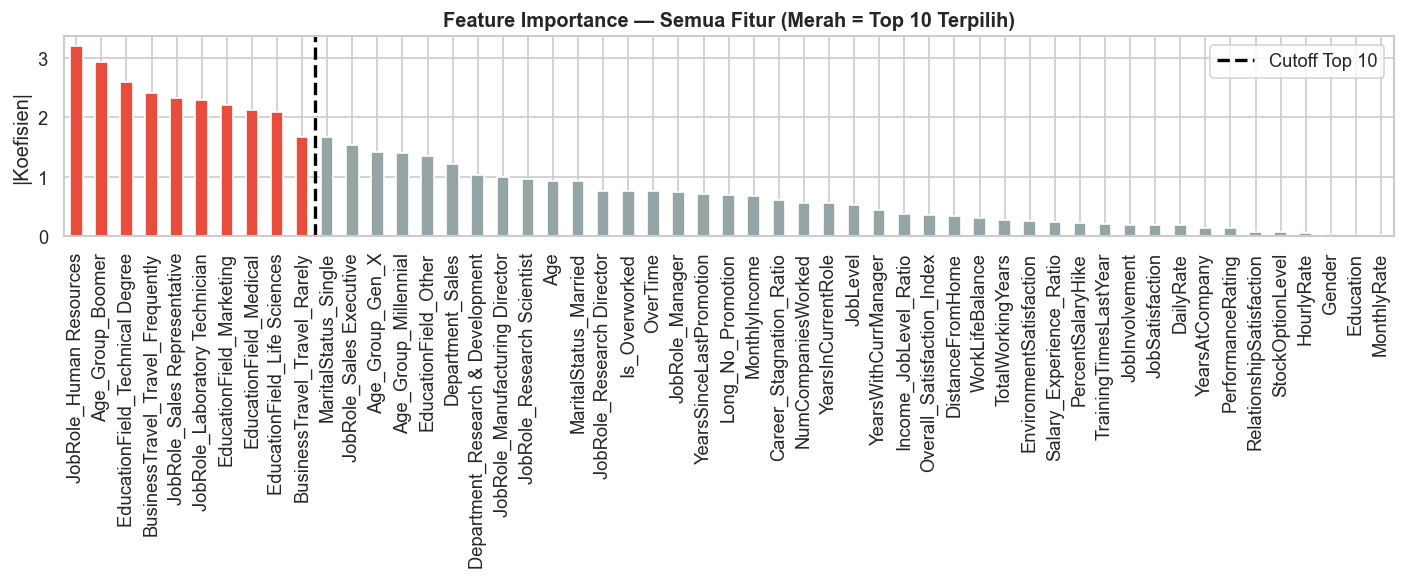

=== TOP 15 FITUR TERPILIH ===
   1. JobRole_Human Resources                 : +3.2026 (↑ Meningkatkan resign)
   2. Age_Group_Boomer                        : +2.9326 (↑ Meningkatkan resign)
   3. EducationField_Technical Degree         : +2.5929 (↑ Meningkatkan resign)
   4. BusinessTravel_Travel_Frequently        : +2.4147 (↑ Meningkatkan resign)
   5. JobRole_Sales Representative            : +2.3323 (↑ Meningkatkan resign)
   6. JobRole_Laboratory Technician           : +2.2910 (↑ Meningkatkan resign)
   7. EducationField_Marketing                : +2.2003 (↑ Meningkatkan resign)
   8. EducationField_Medical                  : +2.1222 (↑ Meningkatkan resign)
   9. EducationField_Life Sciences            : +2.0955 (↑ Meningkatkan resign)
  10. BusinessTravel_Travel_Rarely            : +1.6666 (↑ Meningkatkan resign)
  11. MaritalStatus_Single                    : +1.6665 (↑ Meningkatkan resign)
  12. JobRole_Sales Executive                 : +1.5401 (↑ Meningkatkan resign)
  13. Age_

In [174]:
# Ambil koefisien dari Logistic Regression
coef = pd.Series(best_model.coef_[0], index=X.columns)
top_features_abs = coef.abs().sort_values(ascending=False)

# Visualisasi top 10 vs sisanya
fig, ax = plt.subplots(figsize=(12, 5))
colors_sel = ['#e74c3c' if i < 10 else '#95a5a6' for i in range(len(top_features_abs))]
top_features_abs.plot(kind='bar', ax=ax, color=colors_sel, edgecolor='white')
ax.axvline(9.5, color='black', linestyle='--', linewidth=2, label='Cutoff Top 10')
ax.set_title('Feature Importance — Semua Fitur (Merah = Top 10 Terpilih)',
             fontweight='bold')
ax.set_ylabel('|Koefisien|')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.savefig('../presentation/ml_feature_selection.png', bbox_inches='tight')
plt.show()

# Pilih top 8 fitur
TOP_N = 15
selected_features = top_features_abs.head(TOP_N).index.tolist()

print(f'=== TOP {TOP_N} FITUR TERPILIH ===')
for i, feat in enumerate(selected_features, 1):
    arah = '↑ Meningkatkan resign' if coef[feat] > 0 else '↓ Menurunkan resign'
    print(f'  {i:2}. {feat:<40}: {coef[feat]:+.4f} ({arah})')

# Retrain model dengan fitur terpilih saja
X_train_sel = pd.DataFrame(X_train_sm, columns=X.columns)[selected_features]
X_test_sel  = pd.DataFrame(X_test, columns=X.columns)[selected_features]

best_model_sel = LogisticRegression(max_iter=1000, random_state=42)
best_model_sel.fit(X_train_sel, y_train_sm)

y_pred_sel = best_model_sel.predict(X_test_sel)
y_prob_sel = best_model_sel.predict_proba(X_test_sel)[:, 1]

print(f'\n=== PERBANDINGAN: SEMUA FITUR vs TOP {TOP_N} FITUR ===')
print(f'{"Metric":<12} {"Semua Fitur":>12} {"Top 10 Fitur":>13}')
print('-' * 40)
for metric, fn in [('Accuracy',  accuracy_score),
                   ('Precision', precision_score),
                   ('Recall',    recall_score),
                   ('F1-Score',  f1_score)]:
    full  = fn(y_test, best_model.predict(X_test))
    sel   = fn(y_test, y_pred_sel)
    diff  = sel - full
    arrow = '↑' if diff > 0 else '↓'
    print(f'{metric:<12} {full:>12.4f} {sel:>13.4f}  {arrow}{abs(diff):.4f}')

auc_full = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
auc_sel  = roc_auc_score(y_test, y_prob_sel)
diff_auc = auc_sel - auc_full
arrow = '↑' if diff_auc > 0 else '↓'
print(f'{"AUC-ROC":<12} {auc_full:>12.4f} {auc_sel:>13.4f}  {arrow}{abs(diff_auc):.4f}')

In [175]:
# Keputusan: pakai semua fitur karena drop F1 terlalu besar
f1_full = f1_score(y_test, best_model.predict(X_test))
f1_sel  = f1_score(y_test, y_pred_sel)

print('=== KEPUTUSAN FEATURE SELECTION ===')
print(f'❌ Top {TOP_N} fitur tidak cukup — F1 drop {abs(f1_full-f1_sel):.4f}')
print(f'✅ Keputusan: Pakai SEMUA FITUR untuk akurasi optimal')
print(f'   Alasan: Perbedaan F1 terlalu besar ({f1_full:.4f} vs {f1_sel:.4f})')

final_model      = best_model
final_features   = X.columns.tolist()
final_model_name = best_model_name

print(f'\n   Model final  : {final_model_name}')
print(f'   Jumlah fitur : {len(final_features)}')

# Simpan model & fitur final
os.makedirs('../models', exist_ok=True)
joblib.dump(final_model,       '../models/best_model.pkl')
joblib.dump(final_features,    '../models/feature_columns.pkl')
joblib.dump(OPTIMAL_THRESHOLD, '../models/optimal_threshold.pkl')

print(f'\n✅ Model final tersimpan!')
print(f'✅ Feature columns tersimpan!')
print(f'✅ Optimal threshold tersimpan: {OPTIMAL_THRESHOLD}')

=== KEPUTUSAN FEATURE SELECTION ===
❌ Top 15 fitur tidak cukup — F1 drop 0.1936
✅ Keputusan: Pakai SEMUA FITUR untuk akurasi optimal
   Alasan: Perbedaan F1 terlalu besar (0.4524 vs 0.2588)

   Model final  : Logistic Regression
   Jumlah fitur : 53

✅ Model final tersimpan!
✅ Feature columns tersimpan!
✅ Optimal threshold tersimpan: 0.2


**Learning Curve — Semua Model**

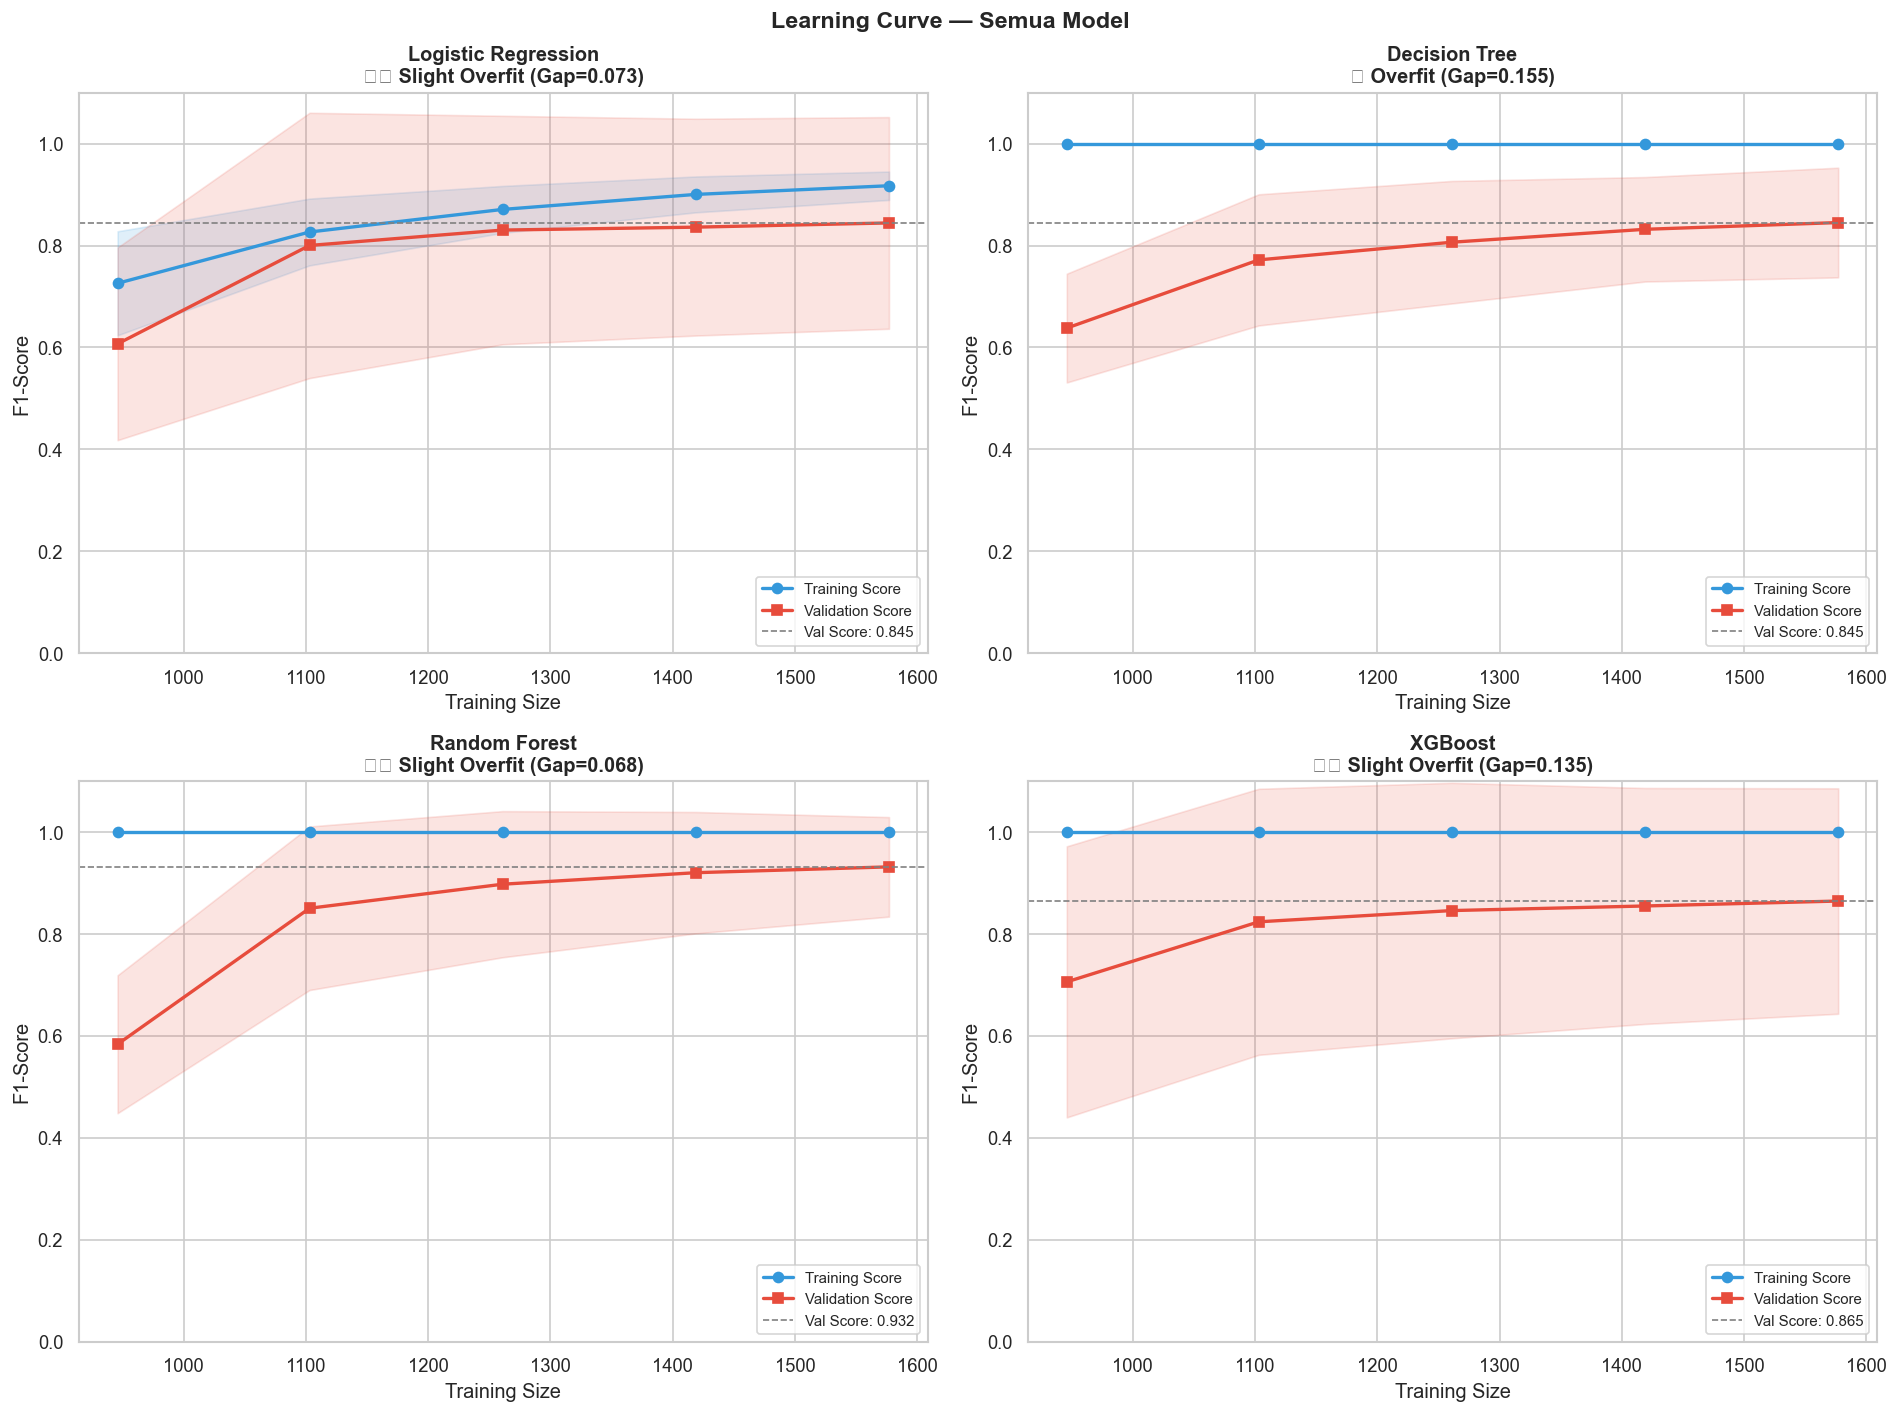

In [176]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_sm, y_train_sm,
        cv=5, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    axes[idx].plot(train_sizes, train_mean, 'o-',
                   color='#3498db', label='Training Score', linewidth=2)
    axes[idx].fill_between(train_sizes,
                           train_mean - train_std,
                           train_mean + train_std,
                           alpha=0.15, color='#3498db')
    axes[idx].plot(train_sizes, val_mean, 's-',
                   color='#e74c3c', label='Validation Score', linewidth=2)
    axes[idx].fill_between(train_sizes,
                           val_mean - val_std,
                           val_mean + val_std,
                           alpha=0.15, color='#e74c3c')
    axes[idx].axhline(val_mean[-1], linestyle='--',
                      color='gray', linewidth=1,
                      label=f'Val Score: {val_mean[-1]:.3f}')

    gap = train_mean[-1] - val_mean[-1]
    if gap < 0.05:
        status = '✅ Good Fit'
    elif gap < 0.15:
        status = '⚠️ Slight Overfit'
    else:
        status = '❌ Overfit'

    axes[idx].set_title(f'{name}\n{status} (Gap={gap:.3f})', fontweight='bold')
    axes[idx].set_xlabel('Training Size')
    axes[idx].set_ylabel('F1-Score')
    axes[idx].legend(loc='lower right', fontsize=9)
    axes[idx].set_ylim(0, 1.1)

plt.suptitle('Learning Curve — Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../presentation/ml_10_learning_curve.png', bbox_inches='tight')
plt.show()

**Business Impact Analysis**

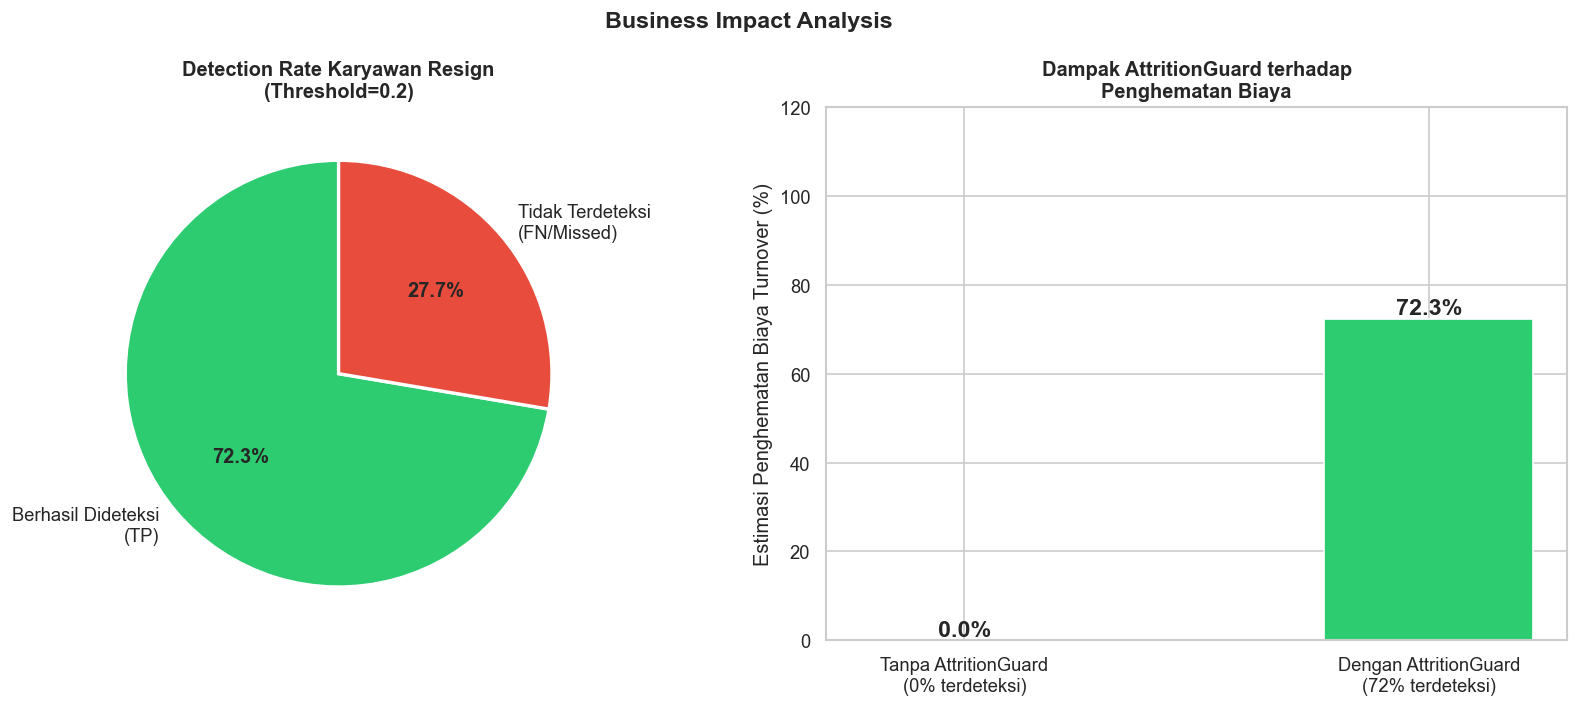

                 💰 BUSINESS IMPACT ANALYSIS                 

📊 HASIL PREDIKSI (Threshold = 0.2)
   Total karyawan resign          : 47
   Berhasil dideteksi (TP)        : 34 (72.3%)
   Tidak terdeteksi / Missed (FN) : 13 (27.7%)
   False Alarm (FP)               : 67

💸 ESTIMASI DAMPAK FINANSIAL
   Asumsi: biaya turnover = 6x gaji bulanan per karyawan

   → Tanpa AttritionGuard  : 100% biaya turnover tetap terjadi
   → Dengan AttritionGuard : 72.3% karyawan resign
     berhasil dideteksi & dapat diintervensi lebih awal

   → Estimasi penghematan  : 72.3% dari total
     biaya turnover perusahaan

✅ KESIMPULAN
   AttritionGuard memungkinkan HR melakukan intervensi dini
   seperti salary review, mentoring, dan program retensi
   sebelum karyawan benar-benar mengundurkan diri.



In [177]:
y_pred_optimal = (best_model.predict_proba(X_test)[:, 1] >= OPTIMAL_THRESHOLD).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_optimal)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

total_resign = tp_o + fn_o
detected     = tp_o
missed       = fn_o
false_alarm  = fp_o

# Visualisasi business impact
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Detection rate
labels_det = ['Berhasil Dideteksi\n(TP)', 'Tidak Terdeteksi\n(FN/Missed)']
values_det = [detected, missed]
colors_det = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[0].pie(
    values_det, labels=labels_det, colors=colors_det,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[0].set_title(f'Detection Rate Karyawan Resign\n(Threshold={OPTIMAL_THRESHOLD})',
                  fontweight='bold')

# Perbandingan tanpa vs dengan model
scenario = ['Tanpa AttritionGuard\n(0% terdeteksi)',
            'Dengan AttritionGuard\n({:.0f}% terdeteksi)'.format(detected/total_resign*100)]
penghematan = [0, detected/total_resign*100]
colors_scen = ['#e74c3c', '#2ecc71']
bars = axes[1].bar(scenario, penghematan,
                   color=colors_scen, edgecolor='white', width=0.45)
for bar, val in zip(bars, penghematan):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Estimasi Penghematan Biaya Turnover (%)')
axes[1].set_title('Dampak AttritionGuard terhadap\nPenghematan Biaya', fontweight='bold')
axes[1].set_ylim(0, 120)

plt.suptitle('Business Impact Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../presentation/ml_11_business_impact.png', bbox_inches='tight')
plt.show()

print('=' * 60)
print('💰 BUSINESS IMPACT ANALYSIS'.center(60))
print('=' * 60)
print(f'''
📊 HASIL PREDIKSI (Threshold = {OPTIMAL_THRESHOLD})
   Total karyawan resign          : {total_resign}
   Berhasil dideteksi (TP)        : {detected} ({detected/total_resign*100:.1f}%)
   Tidak terdeteksi / Missed (FN) : {missed} ({missed/total_resign*100:.1f}%)
   False Alarm (FP)               : {false_alarm}

💸 ESTIMASI DAMPAK FINANSIAL
   Asumsi: biaya turnover = 6x gaji bulanan per karyawan

   → Tanpa AttritionGuard  : 100% biaya turnover tetap terjadi
   → Dengan AttritionGuard : {detected/total_resign*100:.1f}% karyawan resign
     berhasil dideteksi & dapat diintervensi lebih awal
     
   → Estimasi penghematan  : {detected/total_resign*100:.1f}% dari total
     biaya turnover perusahaan

✅ KESIMPULAN
   AttritionGuard memungkinkan HR melakukan intervensi dini
   seperti salary review, mentoring, dan program retensi
   sebelum karyawan benar-benar mengundurkan diri.
''')
print('=' * 60)

**Simpan Model**

In [178]:
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_columns.pkl')
joblib.dump(OPTIMAL_THRESHOLD, '../models/optimal_threshold.pkl')

print('✅ File tersimpan:')
print('  - ../models/best_model.pkl')
print('  - ../models/feature_columns.pkl')
print('  - ../models/optimal_threshold.pkl')
print(f'\nModel   : {best_model_name}')
print(f'Fitur   : {X.shape[1]} kolom')
print(f'Threshold: {OPTIMAL_THRESHOLD}')

✅ File tersimpan:
  - ../models/best_model.pkl
  - ../models/feature_columns.pkl
  - ../models/optimal_threshold.pkl

Model   : Logistic Regression
Fitur   : 53 kolom
Threshold: 0.2


**Ringkasan Machine Learning**

In [179]:
print('=' * 60)
print('RINGKASAN MACHINE LEARNING'.center(60))
print('=' * 60)
print(f'''
📊 DATA
   Dataset       : IBM HR Analytics Employee Attrition
   Total data    : {len(X):,} baris
   Train         : {len(X_train):,} | Test: {len(X_test):,}
   Imbalance fix : SMOTE

🤖 MODEL YANG DIUJI
   1. Logistic Regression
   2. Decision Tree
   3. Random Forest
   4. XGBoost

📈 PERFORMA SEMUA MODEL
''')
print(results_df.to_string())
print(f'''
🏆 MODEL TERBAIK : {best_model_name}
   Accuracy      : {results_df.loc[best_model_name, "Accuracy"]}
   Precision     : {results_df.loc[best_model_name, "Precision"]}
   Recall        : {results_df.loc[best_model_name, "Recall"]}
   F1-Score      : {results_df.loc[best_model_name, "F1-Score"]}
   AUC-ROC       : {results_df.loc[best_model_name, "AUC-ROC"]}

🎯 THRESHOLD OPTIMAL : {OPTIMAL_THRESHOLD}
   (Dipilih untuk memaksimalkan Recall ≥ 0.70)

💰 BUSINESS IMPACT
   Detection Rate  : {detected/total_resign*100:.1f}% karyawan resign berhasil dideteksi
   Estimasi Hemat  : {detected/total_resign*100:.1f}% dari total biaya turnover
''')
print('=' * 60)
print('✅ ML selesai! Siap dilanjutkan ke Deployment (Nabila).')
print('=' * 60)

                 RINGKASAN MACHINE LEARNING                 

📊 DATA
   Dataset       : IBM HR Analytics Employee Attrition
   Total data    : 1,470 baris
   Train         : 1,176 | Test: 294
   Imbalance fix : SMOTE

🤖 MODEL YANG DIUJI
   1. Logistic Regression
   2. Decision Tree
   3. Random Forest
   4. XGBoost

📈 PERFORMA SEMUA MODEL

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.8435     0.5135  0.4043    0.4524   0.8022
XGBoost                0.8673     0.7000  0.2979    0.4179   0.7655
Decision Tree          0.7279     0.2676  0.4043    0.3220   0.5969
Random Forest          0.8299     0.4348  0.2128    0.2857   0.7391

🏆 MODEL TERBAIK : Logistic Regression
   Accuracy      : 0.8435
   Precision     : 0.5135
   Recall        : 0.4043
   F1-Score      : 0.4524
   AUC-ROC       : 0.8022

🎯 THRESHOLD OPTIMAL : 0.2
   (Dipilih untuk memaksimalkan Recall ≥ 0.70)

💰 BUSINESS IMPACT
   Detection Rate  : 72.3% karyawan resign berhasil dide

In [182]:
# Simulasi input yang sama dengan app.py
test_input = {
    'Age': 30, 'BusinessTravel': 'Travel_Frequently',
    'DailyRate': 800, 'Department': 'Sales',
    'DistanceFromHome': 10, 'Education': 1,
    'EducationField': 'Life Sciences', 'EnvironmentSatisfaction': 1,
    'Gender': 'Female', 'HourlyRate': 65,
    'JobInvolvement': 1, 'JobLevel': 1,
    'JobRole': 'Sales Representative', 'JobSatisfaction': 1,
    'MaritalStatus': 'Single', 'MonthlyIncome': 3000,
    'MonthlyRate': 14000, 'NumCompaniesWorked': 5,
    'OverTime': 'Yes', 'PercentSalaryHike': 11,
    'PerformanceRating': 1, 'RelationshipSatisfaction': 1,
    'StockOptionLevel': 0, 'TotalWorkingYears': 2,
    'TrainingTimesLastYear': 2, 'WorkLifeBalance': 1,
    'YearsAtCompany': 1, 'YearsInCurrentRole': 0,
    'YearsSinceLastPromotion': 5, 'YearsWithCurrManager': 0,
}

# Preprocessing manual
df_test = pd.DataFrame([test_input])
df_test['Gender']  = 1 if test_input['Gender']  == 'Male' else 0
df_test['OverTime'] = 1 if test_input['OverTime'] == 'Yes' else 0
onehot_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_test = pd.get_dummies(df_test, columns=onehot_cols, drop_first=True)
df_test['Salary_Experience_Ratio']    = test_input['MonthlyIncome'] / (test_input['TotalWorkingYears'] + 1)
df_test['Career_Stagnation_Ratio']    = test_input['YearsInCurrentRole'] / (test_input['YearsAtCompany'] + 1)
df_test['Overall_Satisfaction_Index'] = np.mean([1, 1, 1, 1])
df_test['Long_No_Promotion']     = 1
df_test['Is_Overworked']         = 1
df_test['Income_JobLevel_Ratio'] = test_input['MonthlyIncome'] / test_input['JobLevel']
age = test_input['Age']
df_test['Age_Group_Millennial'] = 1 if 25 <= age < 35 else 0
df_test['Age_Group_Gen_X']      = 1 if 35 <= age < 45 else 0
df_test['Age_Group_Boomer']     = 1 if age >= 45 else 0

bool_cols = df_test.select_dtypes(include='bool').columns
df_test[bool_cols] = df_test[bool_cols].astype(int)

for col in X_final_scaled.columns:
    if col not in df_test.columns:
        df_test[col] = 0
df_test = df_test[X_final_scaled.columns]

scaler_cols = scaler_final.feature_names_in_.tolist()
common_cols = [c for c in scaler_cols if c in df_test.columns]
df_test[common_cols] = scaler_final.transform(df_test[common_cols])

prob = final_model.predict_proba(df_test)[0][1]
print(f'Probabilitas resign: {prob:.4f} ({prob*100:.2f}%)')
print(f'Prediksi: {"RESIGN" if prob >= OPTIMAL_THRESHOLD else "STAY"}')

Probabilitas resign: 0.1043 (10.43%)
Prediksi: STAY
